# AMN-Style iML1515 FluxTransformer Evaluation

Evaluate a pretrained *E. coli* iML1515 FluxTransformer as a frozen metabolic reservoir for Faure-inspired AMN-style experiments.

Main workflow: load and sanity-check the checkpoint/test data, inspect simulated flux diagnostics, predict experimental growth rate (`GR_AVG`) from medium composition with a small prior dense network, compare against TabPFN baselines, and visualize selected pathway-token embeddings with t-SNE.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [2]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

def format_r2_with_std(r2_value, r2_std):
    std_precision = 3 if abs(float(r2_std)) < 0.005 else 2
    return f"$R^2$ = {r2_value:.2f} $\\pm$ {r2_std:.{std_precision}f}"


In [3]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [4]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [5]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [6]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [7]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [8]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'AMN iML1515 Biomass'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [9]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 1,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)
    pred_vals = []
    true_vals = []
    pos = None

    with torch.inference_mode():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            del xb, yb_true, c, preds_all_layers, selected_indices

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    # Per-flux metrics for the currently plotted token
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = float("nan")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
#model_name = "iML1515_500k_d256_h8_l3_ff1024"
model_name = "AMN_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/AMN_500k_d256_h8_l3_ff1024/AMN_500k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_AMN_training_data_500000_samples.csv
Training samples: 400000
Test samples: 100000


### Load data

In [ ]:
# Load data using the same function as during training
#set_seed()

DATA_PATH = f"./data/iML1515_AMN_test_data_50000_samples.csv"
# DATA_PATH = data_info["dataset"]  # training file; use only for debugging, not reported test metrics
N_EVAL_SAMPLES = 50_000

X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)
if X.shape[0] > N_EVAL_SAMPLES:
    rng = np.random.default_rng(10)
    eval_idx = rng.choice(X.shape[0], size=N_EVAL_SAMPLES, replace=False)
    X = X[eval_idx]
    y = y[eval_idx]
    print(f"Using {N_EVAL_SAMPLES:,} sampled rows from {DATA_PATH} for diagnostics.")

checkpoint_inputs = list(data_info.get("input_cols", []))
if not checkpoint_inputs:
    raise KeyError("Checkpoint data_info is missing 'input_cols'; cannot verify nutrient input set.")

loaded_input_set = set(inputs)
checkpoint_input_set = set(checkpoint_inputs)
missing_from_loaded = sorted(checkpoint_input_set - loaded_input_set)
extra_in_loaded = sorted(loaded_input_set - checkpoint_input_set)
assert loaded_input_set == checkpoint_input_set, (
    "Loaded CSV input set does not match checkpoint data_info['input_cols'].\n"
    f"Missing from loaded CSV: {missing_from_loaded}\n"
    f"Extra in loaded CSV: {extra_in_loaded}"
)
if list(inputs) != checkpoint_inputs:
    print("Warning: loaded CSV input order differs from checkpoint input_cols; continuing because inputs are mapped by token name.")

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()

In [13]:
glycolysis_reactions = [
    "GLCptspp", "GLCt2pp", "HEX1", "PGI", "PFK", "FBA", "TPI",
    "GAPD", "PGK", "PGM", "ENO", "PYK", "PPS", "FBP",
]

ppp_reactions = [
    "G6PDH2r", "PGL", "GND", "RPI", "RPE", "TKT1", "TALA", "TKT2",
]

tca_reactions = [
    "CS", "ACONTa", "ACONTb", "ICDHyr", "AKGDH", "SUCOAS", "SUCDi", "FUM", "MDH",
]

anaplerotic_reactions = [
    "PPC", "PPCK", "ME1", "ME2", "ICL", "MALS",
]

fermentation_reactions = [
    "PFL", "LDH_D", "ACALD", "ALCD2x", "PTAr", "ACKr", "POX",
]

oxphos_reactions = [
    "NADH16pp", "NADH17pp", "NADH18pp", "CYTBO3_4pp", "CYTBDpp", "CYTBD2pp", "ATPS4rpp",
]

nitrogen_reactions = [
    "GLNS", "GLUDy", "GLUN", "GLUSy", "ASPTA", "ALATA_L",
]

pathway_reaction_lists = {
    "glycolysis_reactions": glycolysis_reactions,
    "ppp_reactions": ppp_reactions,
    "tca_reactions": tca_reactions,
    "anaplerotic_reactions": anaplerotic_reactions,
    "fermentation_reactions": fermentation_reactions,
    "oxphos_reactions": oxphos_reactions,
    "nitrogen_reactions": nitrogen_reactions,
}

def _reaction_token_name(reaction_id, token_names):
    reaction_id = str(reaction_id)
    base_id = reaction_id[:-5] if reaction_id.endswith("_flux") else reaction_id
    candidates = (reaction_id, f"{base_id}_flux", base_id)
    token_set = set(token_names)
    for candidate in candidates:
        if candidate in token_set:
            return candidate
    return None

missing_by_pathway = {
    name: [rxn_id for rxn_id in rxn_ids if _reaction_token_name(rxn_id, outputs) is None]
    for name, rxn_ids in pathway_reaction_lists.items()
}
missing_by_pathway = {name: missing for name, missing in missing_by_pathway.items() if missing}
if missing_by_pathway:
    raise ValueError(f"Missing pathway reaction IDs from checkpoint outputs: {missing_by_pathway}")

for name, rxn_ids in pathway_reaction_lists.items():
    print(f"{name} = {rxn_ids!r}")


glycolysis_reactions = ['GLCptspp', 'GLCt2pp', 'HEX1', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK', 'PPS', 'FBP']
ppp_reactions = ['G6PDH2r', 'PGL', 'GND', 'RPI', 'RPE', 'TKT1', 'TALA', 'TKT2']
tca_reactions = ['CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH']
anaplerotic_reactions = ['PPC', 'PPCK', 'ME1', 'ME2', 'ICL', 'MALS']
fermentation_reactions = ['PFL', 'LDH_D', 'ACALD', 'ALCD2x', 'PTAr', 'ACKr', 'POX']
oxphos_reactions = ['NADH16pp', 'NADH17pp', 'NADH18pp', 'CYTBO3_4pp', 'CYTBDpp', 'CYTBD2pp', 'ATPS4rpp']
nitrogen_reactions = ['GLNS', 'GLUDy', 'GLUN', 'GLUSy', 'ASPTA', 'ALATA_L']


In [ ]:
def plot_reaction_subset_tsne(
    model,
    token_names,
    X_context,
    reaction_subset,
    *,
    subset_name=None,
    n_samples=8000,
    perplexity=40.0,
    batch_size=128,
    random_state=10,
    annotate=True,
    annotate_fontsize=15,
    save_path=None,
    print_colors=True,
    sample_color_mode="reaction",  # "reaction", "gray", "rainbow", "viridis", "plasma", or "coolwarm"
    show_pre_embeddings=False,
    return_data=False,
):
    """
    Plot post-layer FluxTransformer token embeddings for a selected reaction subset.

    reaction_subset can be either:
      - a key from pathway_reaction_lists, such as "glycolysis_reactions"
      - a list of reaction IDs, such as glycolysis_reactions
      - a list of flux token names ending in "_flux"

    Each reaction in the subset receives its own color before embeddings are collected.
    With sample_color_mode="gray", all subset-reaction points are plotted in gray.
    With sample_color_mode="rainbow" or another colormap, points are colored by
    nutrient-context similarity while reaction colors are kept only for centers.
    If show_pre_embeddings=True, initial token embeddings are included in the
    same t-SNE fit and plotted as black dots.
    """
    device = next(model.parameters()).device
    model.eval()

    V = int(model.vocab_size)
    if len(token_names) != V:
        raise ValueError(f"len(token_names)={len(token_names)} but model.vocab_size={V}.")

    if isinstance(reaction_subset, str):
        if reaction_subset in pathway_reaction_lists:
            reaction_ids = list(pathway_reaction_lists[reaction_subset])
            subset_label = subset_name or reaction_subset
        else:
            reaction_ids = [reaction_subset]
            subset_label = subset_name or reaction_subset
    else:
        reaction_ids = list(reaction_subset)
        subset_label = subset_name or "reaction subset"

    reaction_ids = list(dict.fromkeys(str(r) for r in reaction_ids))
    if not reaction_ids:
        raise ValueError("reaction_subset is empty.")

    token_lookup = {name: idx for idx, name in enumerate(token_names)}
    selected_token_names = []
    display_reaction_ids = []
    missing = []
    for reaction_id in reaction_ids:
        base_id = reaction_id[:-5] if reaction_id.endswith("_flux") else reaction_id
        candidates = (reaction_id, f"{base_id}_flux", base_id)
        token_name = next((candidate for candidate in candidates if candidate in token_lookup), None)
        if token_name is None:
            missing.append(reaction_id)
            continue
        selected_token_names.append(token_name)
        display_reaction_ids.append(token_name[:-5] if token_name.endswith("_flux") else token_name)

    if missing:
        raise ValueError(f"These reactions are not present in token_names: {missing}")

    token_indices = [token_lookup[name] for name in selected_token_names]
    n_tok = len(token_indices)
    colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_tok))
    from matplotlib.colors import to_hex

    reaction_colors = {
        reaction_id: color
        for reaction_id, color in zip(display_reaction_ids, colors)
    }
    reaction_color_hex = {
        reaction_id: to_hex(color)
        for reaction_id, color in reaction_colors.items()
    }

    mode = str(sample_color_mode).strip().lower()
    allowed_modes = {"reaction", "gray", "rainbow", "viridis", "plasma", "coolwarm"}
    if mode not in allowed_modes:
        raise ValueError("sample_color_mode must be one of: reaction, gray, rainbow, viridis, plasma, coolwarm.")
    use_gray = mode == "gray"
    use_sample_colormap = mode in {"rainbow", "viridis", "plasma", "coolwarm"}

    if print_colors and mode == "reaction":
        print("Reaction colors:")
        for reaction_id in display_reaction_ids:
            print(f"  {reaction_id}: {reaction_color_hex[reaction_id]}")

    if not torch.is_tensor(X_context):
        X_context = torch.tensor(X_context, dtype=torch.float32)
    if X_context.dim() != 2 or X_context.size(1) != V:
        raise ValueError(f"X_context must have shape (N, {V}). Got {tuple(X_context.shape)}")

    N = min(int(n_samples), int(X_context.size(0)))
    if N <= 0:
        raise ValueError("n_samples selects zero contexts.")

    X_norm_cond = None
    if use_sample_colormap:
        X_cond = X_context[:N]
        if torch.is_tensor(X_cond):
            X_cond = X_cond.detach().cpu().numpy()
        else:
            X_cond = np.asarray(X_cond, dtype=np.float32)

        if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
            cond_idx = model.input_token_indices.detach().cpu().numpy().astype(np.int64)
            cond_idx = cond_idx[(cond_idx >= 0) & (cond_idx < X_cond.shape[1])]
            if cond_idx.size > 0:
                X_cond = X_cond[:, cond_idx]

        X_cond = X_cond.astype(np.float64, copy=False)
        mu = np.nanmean(X_cond, axis=0, keepdims=True)
        sigma = np.nanstd(X_cond, axis=0, keepdims=True)
        sigma[sigma < 1e-12] = 1.0
        X_norm_cond = (X_cond - mu) / sigma
        X_norm_cond = np.nan_to_num(X_norm_cond, nan=0.0, posinf=0.0, neginf=0.0)

    token_indices_tensor = torch.tensor(token_indices, dtype=torch.long, device=device)
    pos_in_selected = None
    all_embeddings = []
    token_id_labels = []
    sample_id_labels = []

    with torch.no_grad():
        for start in range(0, N, batch_size):
            stop = min(start + batch_size, N)
            batch_context = X_context[start:stop].to(device).unsqueeze(-1)
            x, selected_indices = model(
                batch_context,
                output_subset=token_indices_tensor,
                return_embedding=True,
            )

            if pos_in_selected is None:
                selected_list = [int(v) for v in selected_indices.detach().cpu().tolist()]
                pos_by_token = {token_idx: pos for pos, token_idx in enumerate(selected_list)}
                missing_selected = [idx for idx in token_indices if idx not in pos_by_token]
                if missing_selected:
                    missing_names = [token_names[idx] for idx in missing_selected]
                    raise RuntimeError(f"Requested tokens were not returned by the model: {missing_names}")
                pos_in_selected = torch.tensor(
                    [pos_by_token[idx] for idx in token_indices],
                    dtype=torch.long,
                    device=device,
                )

            keep_x = x.index_select(1, pos_in_selected)
            batch_size_actual = stop - start
            all_embeddings.append(keep_x.detach().cpu())
            token_id_labels.append(np.tile(np.arange(n_tok, dtype=np.int64), batch_size_actual))
            sample_id_labels.append(np.repeat(np.arange(start, stop, dtype=np.int64), n_tok))

    all_embeddings = torch.cat(all_embeddings, dim=0)
    token_id_labels = np.concatenate(token_id_labels, axis=0)
    sample_id_labels = np.concatenate(sample_id_labels, axis=0)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    n_points = embeddings_flat.shape[0]
    if n_points < 3:
        raise ValueError(f"Need at least 3 embedding points for t-SNE, got {n_points}.")

    pre_embeddings = None
    embeddings_for_tsne = embeddings_flat
    if show_pre_embeddings:
        if not hasattr(model, "input_embedding"):
            raise AttributeError("show_pre_embeddings=True requires model.input_embedding.")
        with torch.no_grad():
            pre_embeddings = model.input_embedding(token_indices_tensor).detach().cpu().numpy()
        embeddings_for_tsne = np.concatenate([embeddings_flat, pre_embeddings], axis=0)

    n_points_joint = embeddings_for_tsne.shape[0]
    if perplexity >= n_points_joint:
        new_perplexity = max(1.0, min(30.0, (n_points_joint - 1) / 3.0))
        print(f"[plot_reaction_subset_tsne] Adjusting perplexity {perplexity} -> {new_perplexity:.2f} (n_points={n_points_joint})")
        perplexity = float(new_perplexity)

    emb2d_joint = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
    ).fit_transform(embeddings_for_tsne)
    emb2d = emb2d_joint[:n_points]
    pre_emb2d = emb2d_joint[n_points:] if show_pre_embeddings else None

    base_s = 10.0
    base_alpha = 0.22
    center_s = 36.0
    if n_tok <= 20:
        base_s = 30.0
        base_alpha = 0.38
        center_s = 72.0
    if n_tok <= 10:
        base_s = 36.0
        base_alpha = 0.48
        center_s = 86.0

    rainbow_order = np.arange(N, dtype=np.int64)
    if use_sample_colormap and X_norm_cond is not None and N > 1:
        start_idx = int(np.argmin(np.sum((X_norm_cond - X_norm_cond.mean(axis=0, keepdims=True)) ** 2, axis=1)))
        order = np.empty(N, dtype=np.int64)
        unvisited = np.ones(N, dtype=bool)
        current = start_idx
        for order_pos in range(N):
            order[order_pos] = current
            unvisited[current] = False
            if order_pos == N - 1:
                break
            remaining = np.flatnonzero(unvisited)
            distances = np.sum((X_norm_cond[remaining] - X_norm_cond[current]) ** 2, axis=1)
            current = int(remaining[np.argmin(distances)])
        rainbow_order = order

    discrete_cmap = ListedColormap(colors)
    plt.figure(figsize=(16, 12))
    if use_gray:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c="#b5b5b5",
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )
    elif use_sample_colormap:
        if N > 1:
            sample_rank = np.empty(N, dtype=np.int64)
            sample_rank[rainbow_order] = np.arange(N, dtype=np.int64)
            sample_norm = sample_rank[sample_id_labels].astype(np.float64) / float(N - 1)
        else:
            sample_norm = np.zeros_like(sample_id_labels, dtype=np.float64)
        cmap = plt.cm.rainbow_r if mode == "rainbow" else plt.get_cmap(mode)
        point_colors = cmap(sample_norm)
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=point_colors,
            alpha=max(base_alpha, 0.70),
            s=base_s,
            edgecolors="none",
        )
    else:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=token_id_labels,
            cmap=discrete_cmap,
            vmin=0,
            vmax=max(1, n_tok - 1),
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )

    centers = []
    for local_idx in range(n_tok):
        mask = token_id_labels == local_idx
        if np.any(mask):
            centers.append((local_idx, np.median(emb2d[mask], axis=0)))

    for local_idx, center in centers:
        label = display_reaction_ids[local_idx]
        center_color = "#8a8a8a" if use_gray else colors[local_idx]
        plt.scatter(
            center[0],
            center[1],
            s=center_s,
            marker="o",
            color=center_color,
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        if annotate:
            plt.annotate(
                label,
                center,
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=annotate_fontsize,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
            )

    if show_pre_embeddings:
        plt.scatter(
            pre_emb2d[:, 0],
            pre_emb2d[:, 1],
            c="black",
            alpha=0.95,
            s=max(center_s, 120.0),
            edgecolors="white",
            linewidths=0.8,
            zorder=4,
            label="Pre-token embeddings",
        )
        print(f"Pre-embedding points plotted: {len(pre_emb2d)}")

    if mode == "reaction":
        legend_handles = [
            mpatches.Patch(color=colors[i], label=display_reaction_ids[i])
            for i in range(n_tok)
        ]
        reaction_legend = plt.legend(
            handles=legend_handles,
            title="Reaction",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            fontsize=13,
            title_fontsize=14,
            frameon=False,
        )
        if show_pre_embeddings:
            pre_handle = plt.Line2D(
                [0], [0], marker="o", color="none", label="Pre-token embeddings",
                markerfacecolor="black", markeredgecolor="white", markeredgewidth=0.8,
                markersize=9,
            )
            plt.gca().add_artist(reaction_legend)
            plt.legend(handles=[pre_handle], loc="upper right", fontsize=15, frameon=True)
    elif show_pre_embeddings:
        plt.legend(loc="upper right", fontsize=15, frameon=True)
    plt.title(
        f"Post-layer Token Embeddings (t-SNE): {subset_label}\n"
        f"(n_contexts={N}, n_tokens={n_tok})",
        fontsize=26,
    )
    plt.xlabel("t-SNE 1", fontsize=22)
    plt.ylabel("t-SNE 2", fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(alpha=0.1)
    plt.tight_layout()

    if save_path:
        save_dir = os.path.dirname(str(save_path))
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
    plt.show()
    plt.close()

    if return_data:
        return {
            "embedding_2d": emb2d,
            "token_id_labels": token_id_labels,
            "reaction_ids": display_reaction_ids,
            "reaction_colors": reaction_color_hex,
            "sample_id_labels": sample_id_labels,
            "sample_color_mode": mode,
            "pre_embedding_2d": pre_emb2d,
        }

# Example:
# plot_reaction_subset_tsne(
#     model,
#     outputs,
#     X_test,
#     "glycolysis_reactions",
#     n_samples=8000,
#     perplexity=40.0,
#     save_path=f"{pic_dir}/{model_name}_tsne_glycolysis_reactions",
# )


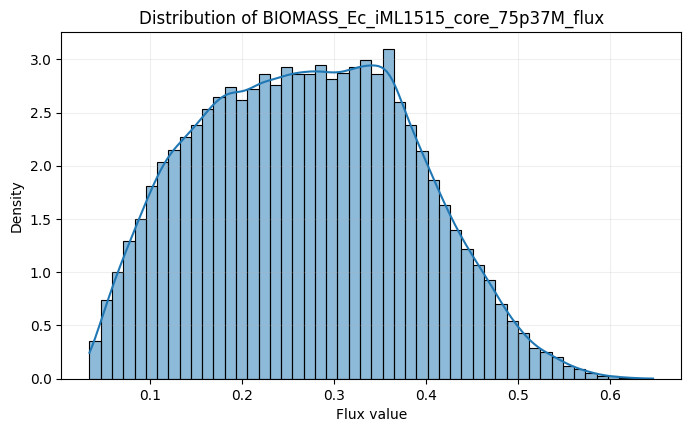

In [15]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_core_75p37M_flux")

### Plot Results

In [16]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

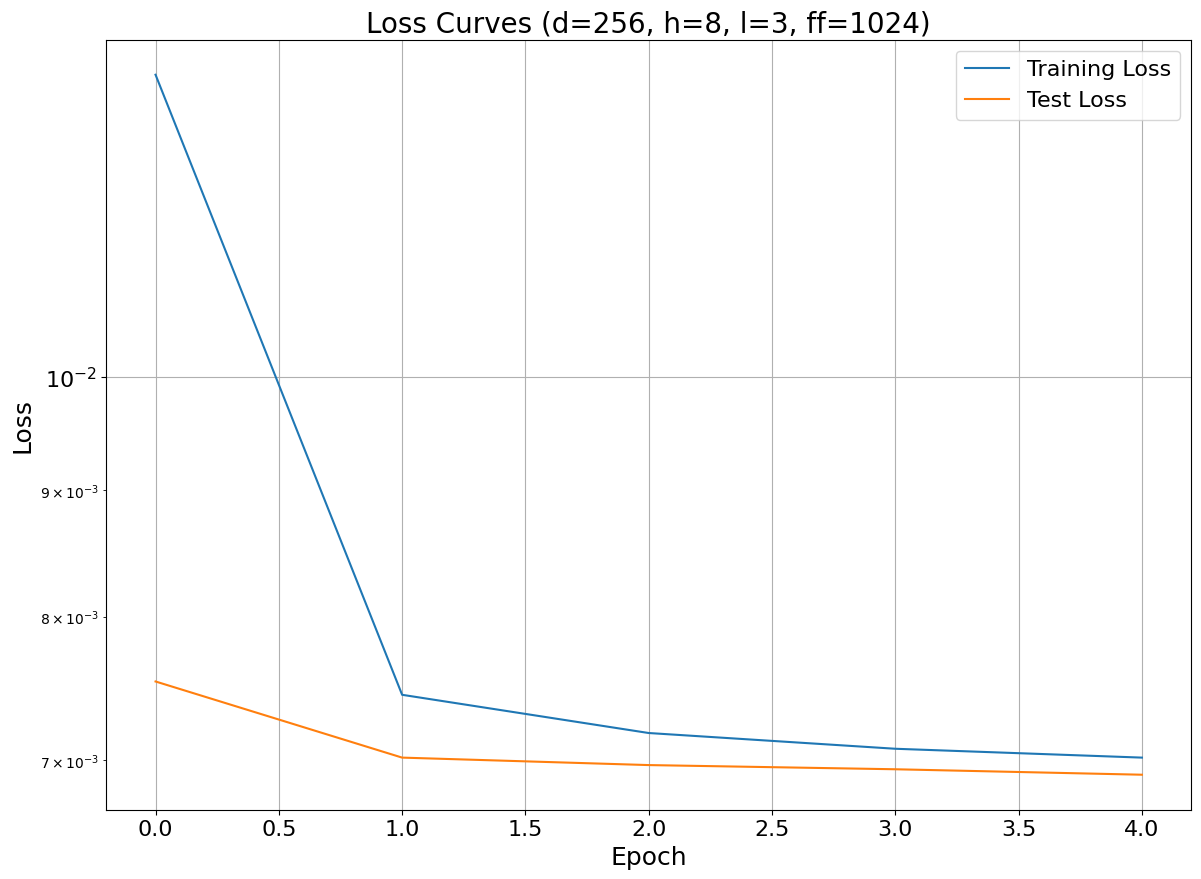

In [17]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_core_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_core_75p37M_flux token index: 2668
injected medium slot: False
y_true range: 0.03446776047348976 to 0.6248172521591187
y_pred range: 0.046162813901901245 to 0.6119295358657837
R2: 0.9921
MAE: 0.008691
RMSE: 0.010093


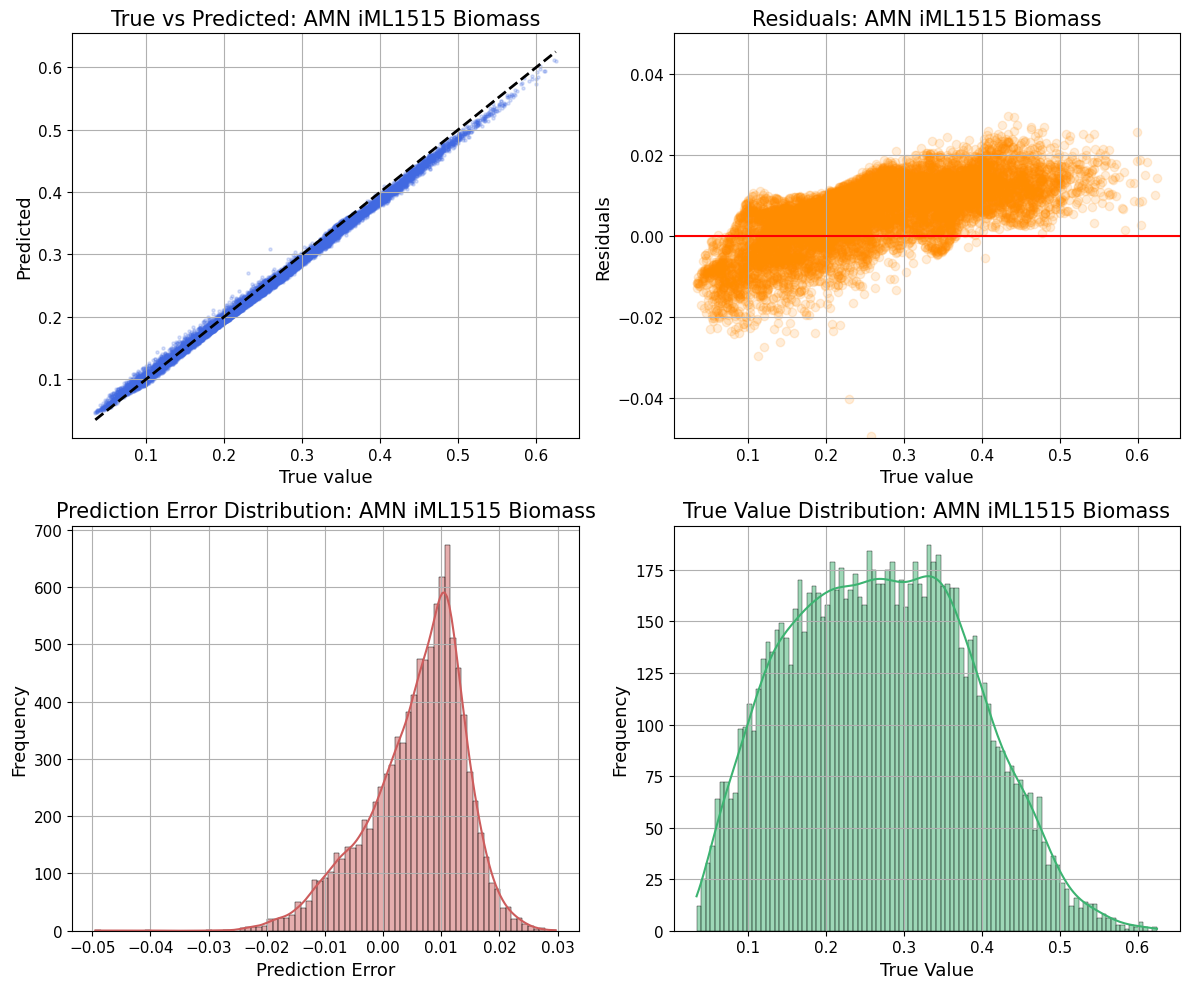

In [18]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=save_path)

GLUDy_flux:
------------------------------------------------------------
GLUDy_flux token index: 1404
injected medium slot: False
y_true range: -1.4758745431900024 to 2.3570940494537354
y_pred range: -0.7244042158126831 to 2.060567617416382
R2: 0.7723
MAE: 0.212300
RMSE: 0.324331


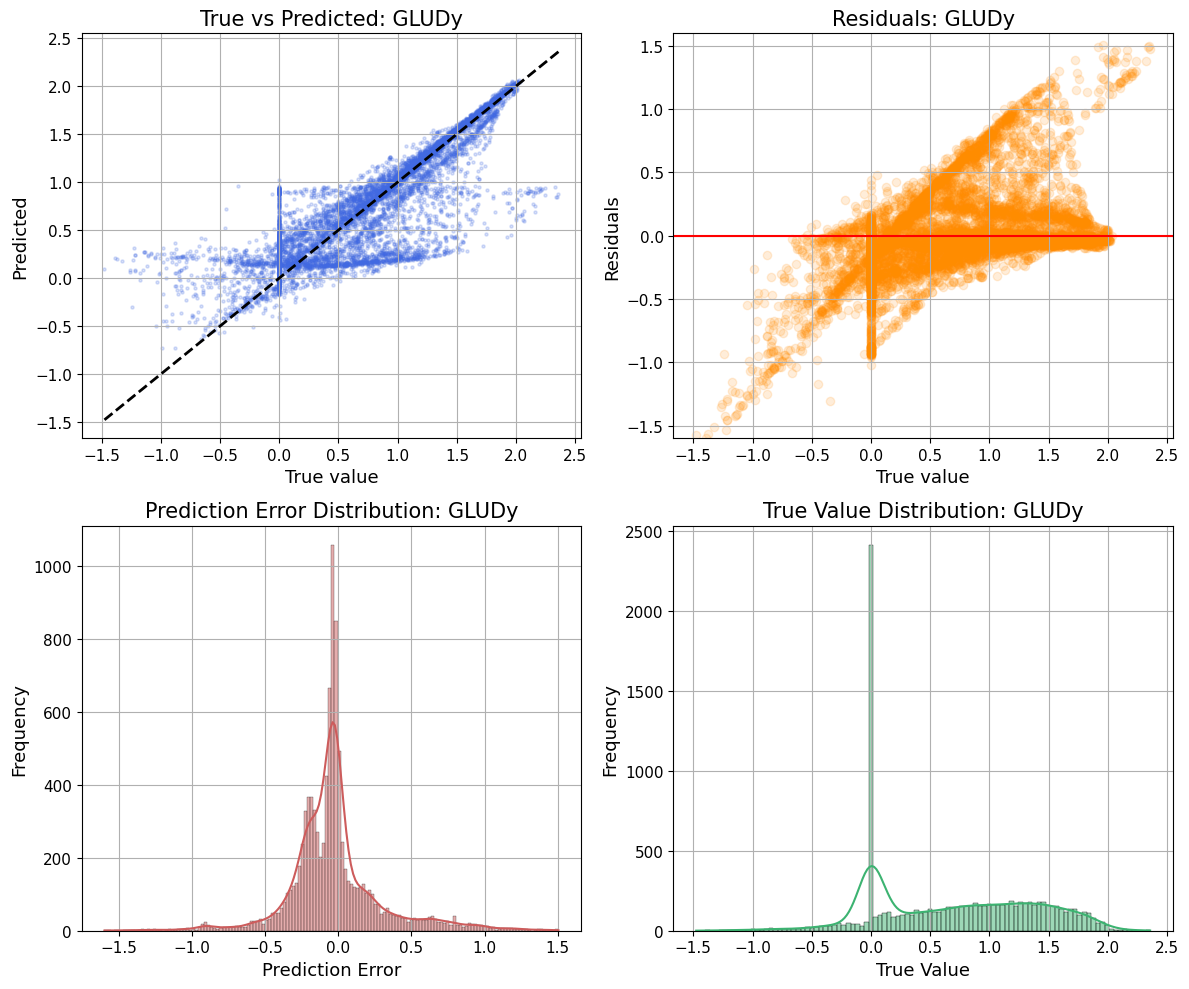

EX_co2_e_flux:
------------------------------------------------------------
EX_co2_e_flux token index: 45
injected medium slot: True
y_true range: -0.7630305886268616 to 12.29786205291748
y_pred range: 0.09604835510253906 to 12.071514129638672
R2: 0.9890
MAE: 0.165366
RMSE: 0.320422


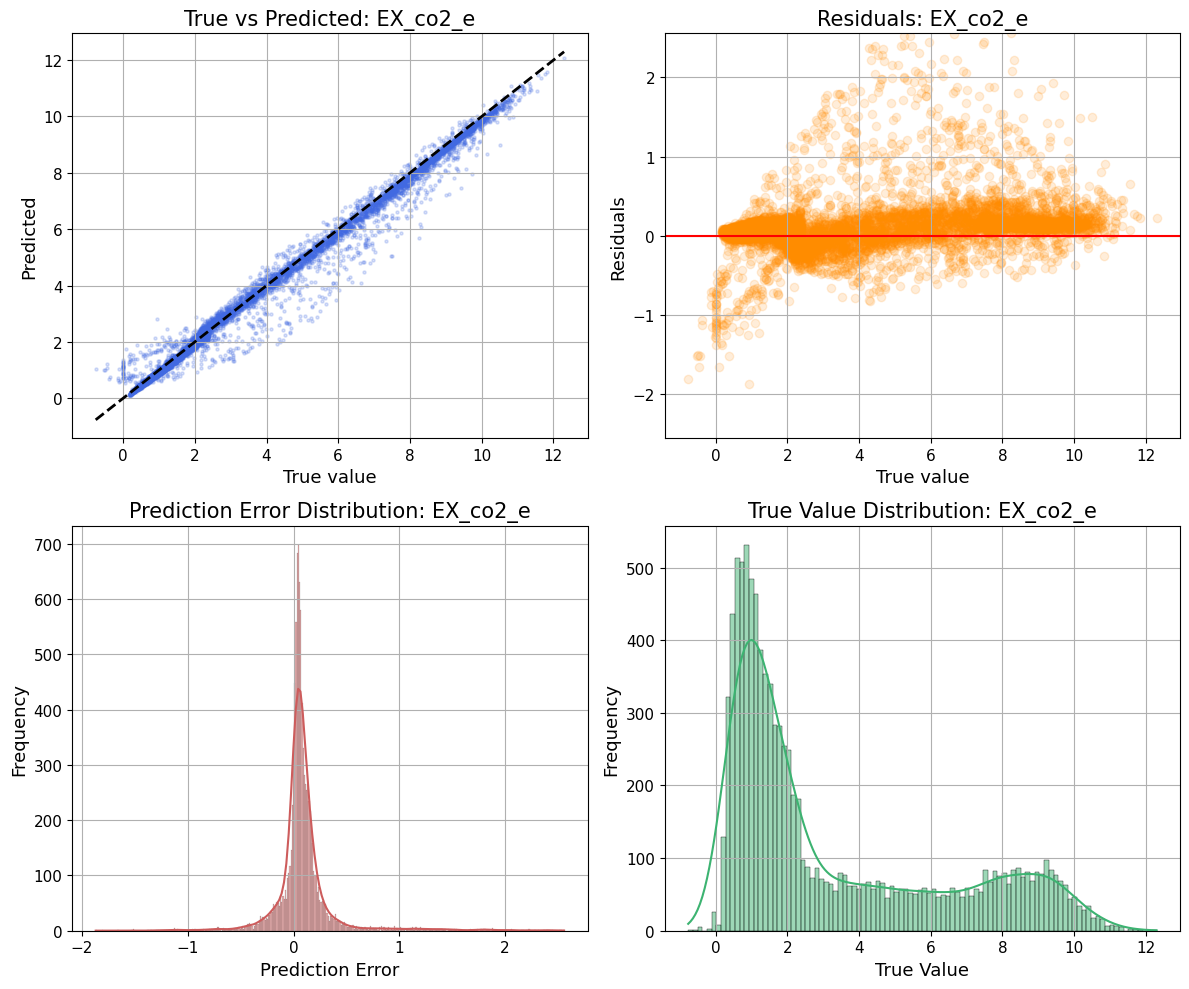

O2tpp_flux:
------------------------------------------------------------
O2tpp_flux token index: 734
injected medium slot: False
y_true range: 1.0 to 10.0
y_pred range: 1.0738645792007446 to 9.923622131347656
R2: 0.9993
MAE: 0.061886
RMSE: 0.069599


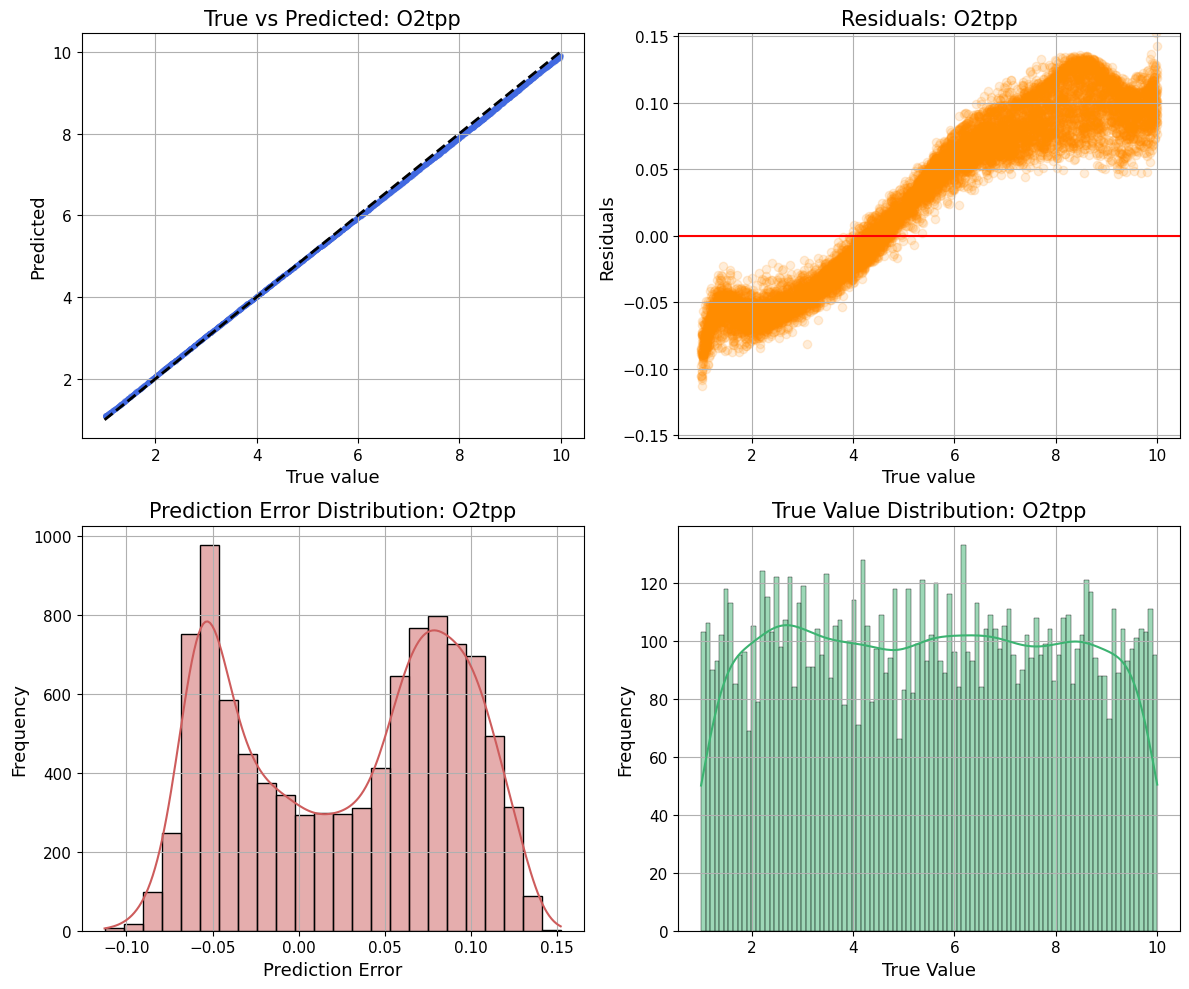

In [36]:
diagnostics_to_plot = ['GLUDy_flux', 'EX_co2_e_flux', 'O2tpp_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

In [37]:
# Overall model metrics across all output fluxes (flattened)
def _compute_overall_metrics(model_ref, X_ref, y_ref, outputs_ref, device_ref, batch_size_ref):
    model_eval = model_ref.to(device_ref).eval()
    V = len(outputs_ref)

    if X_ref.shape[1] != V or y_ref.shape[1] != V:
        raise ValueError(
            f"Expected X_test/y_test second dim == len(outputs)={V}, got {X_ref.shape[1]} and {y_ref.shape[1]}"
        )

    pred_batches = []
    true_batches = []
    perm = None
    use_amp = device_ref.type == "cuda"

    with torch.inference_mode():
        for i in range(0, X_ref.shape[0], batch_size_ref):
            xb = X_ref[i:i + batch_size_ref].to(device_ref)
            yb_true = y_ref[i:i + batch_size_ref]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)
            else:
                preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)

            preds_last = preds_all_layers[:, :, -1]  # (B, S)

            if perm is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                selected_indices_np = selected_indices_np.astype(int)

                if selected_indices_np.size != V:
                    raise RuntimeError(f"Model returned {selected_indices_np.size} outputs, expected {V}.")

                inv = np.full(V, -1, dtype=np.int64)
                inv[selected_indices_np] = np.arange(selected_indices_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Missing output indices in model forward pass: {missing[:10]}")
                perm = torch.as_tensor(inv, device=preds_last.device, dtype=torch.long)

            yb_pred = preds_last.index_select(1, perm).detach().cpu().numpy().astype(np.float32, copy=False)
            pred_batches.append(yb_pred)
            true_batches.append(yb_true.detach().cpu().numpy().astype(np.float32, copy=False))

            del xb, preds_all_layers, preds_last, selected_indices
            if device_ref.type == "cuda":
                torch.cuda.empty_cache()

    y_pred_full = np.concatenate(pred_batches, axis=0)
    y_true_full = np.concatenate(true_batches, axis=0)

    overall_r2 = r2_score(y_true_full.ravel(), y_pred_full.ravel())
    overall_mae = mean_absolute_error(y_true_full.ravel(), y_pred_full.ravel())
    overall_rmse = root_mean_squared_error(y_true_full.ravel(), y_pred_full.ravel())
    return overall_r2, overall_mae, overall_rmse

original_device = next(model.parameters()).device
preferred_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if preferred_device.type == "cuda":
    batch_size_metrics = 2
else:
    batch_size_metrics = 32

used_device = preferred_device
try:
    overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
        model, X_test, y_test, outputs, preferred_device, batch_size_metrics
    )
except RuntimeError as e:
    if preferred_device.type == "cuda" and "out of memory" in str(e).lower():
        print("CUDA OOM during overall metrics; falling back to CPU...")
        torch.cuda.empty_cache()
        used_device = torch.device("cpu")
        overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
            model, X_test, y_test, outputs, used_device, 32
        )
    else:
        raise
finally:
    model.to(original_device)

print("Overall model metrics (all fluxes, flattened):")
print(f"Device used: {used_device}")
print(f"R2:   {overall_r2:.4f}")
print(f"MAE:  {overall_mae:.6f}")
print(f"RMSE: {overall_rmse:.6f}")

Overall model metrics (all fluxes, flattened):
Device used: cuda
R2:   0.9720
MAE:  0.016333
RMSE: 0.174556


Reaction colors:
  GLCptspp: #700080
  GLCt2pp: #58009f
  HEX1: #0000d1
  PGI: #007add
  PFK: #00a2c3
  FBA: #00aa8b
  TPI: #00a400
  GAPD: #00d200
  PGK: #0fff00
  PGM: #d4f700
  ENO: #fdcf00
  PYK: #ff7500
  PPS: #e90000
  FBP: #cc0c0c
Plot saved to ./pics/2026-07-09/AMN_500k_d256_h8_l3_ff1024/AMN_500k_d256_h8_l3_ff1024_tsne_glycolysis_reactions


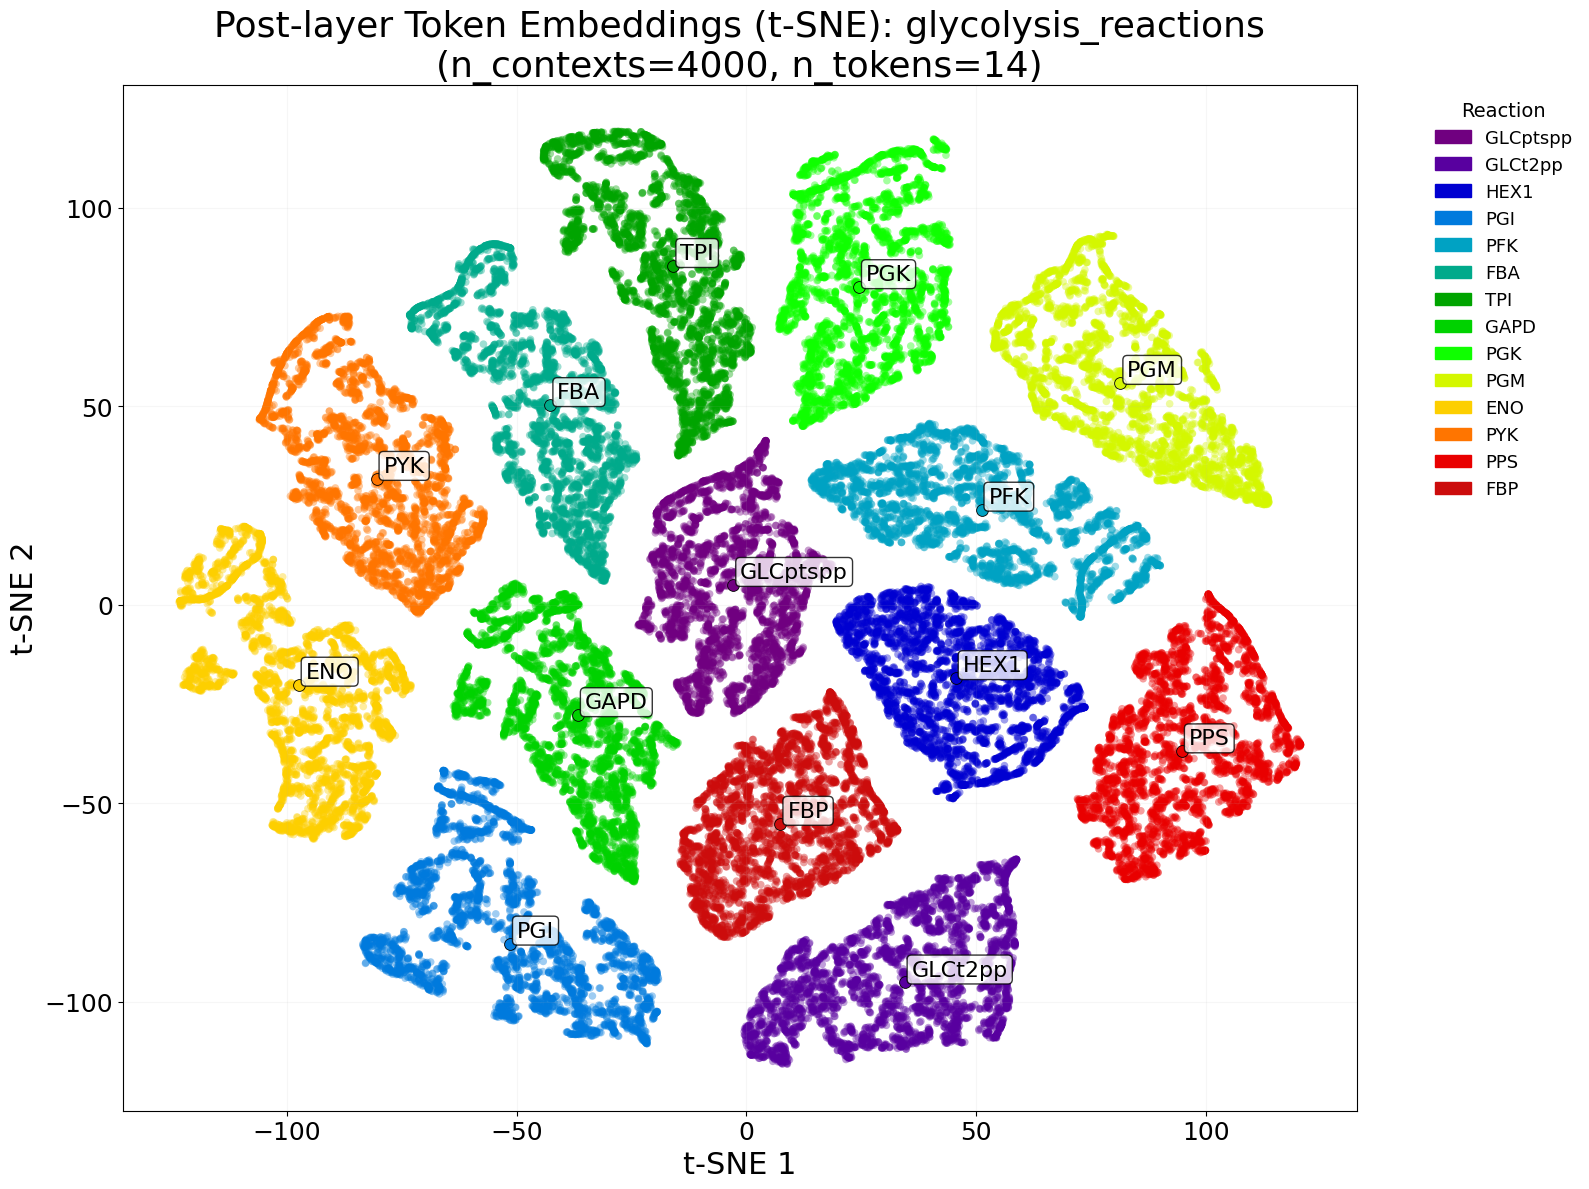

In [38]:
save_path = f"{pic_dir}/{model_name}_tsne_glycolysis_reactions"

plot_reaction_subset_tsne(
    model,
    outputs,
    X_test,
    glycolysis_reactions,
    subset_name="glycolysis_reactions",
    n_samples=4000,
    perplexity=40.0,
    annotate=True,
    annotate_fontsize=16,
    save_path=save_path,
)


Reaction colors:
  G6PDH2r: #700080
  PGL: #0000c5
  GND: #009bd7
  RPI: #009e28
  RPE: #00e700
  TKT1: #e8f000
  TALA: #ff5100
  TKT2: #cc0c0c
Plot saved to ./pics/2026-07-09/AMN_500k_d256_h8_l3_ff1024/AMN_500k_d256_h8_l3_ff1024_tsne_ppp_reactions


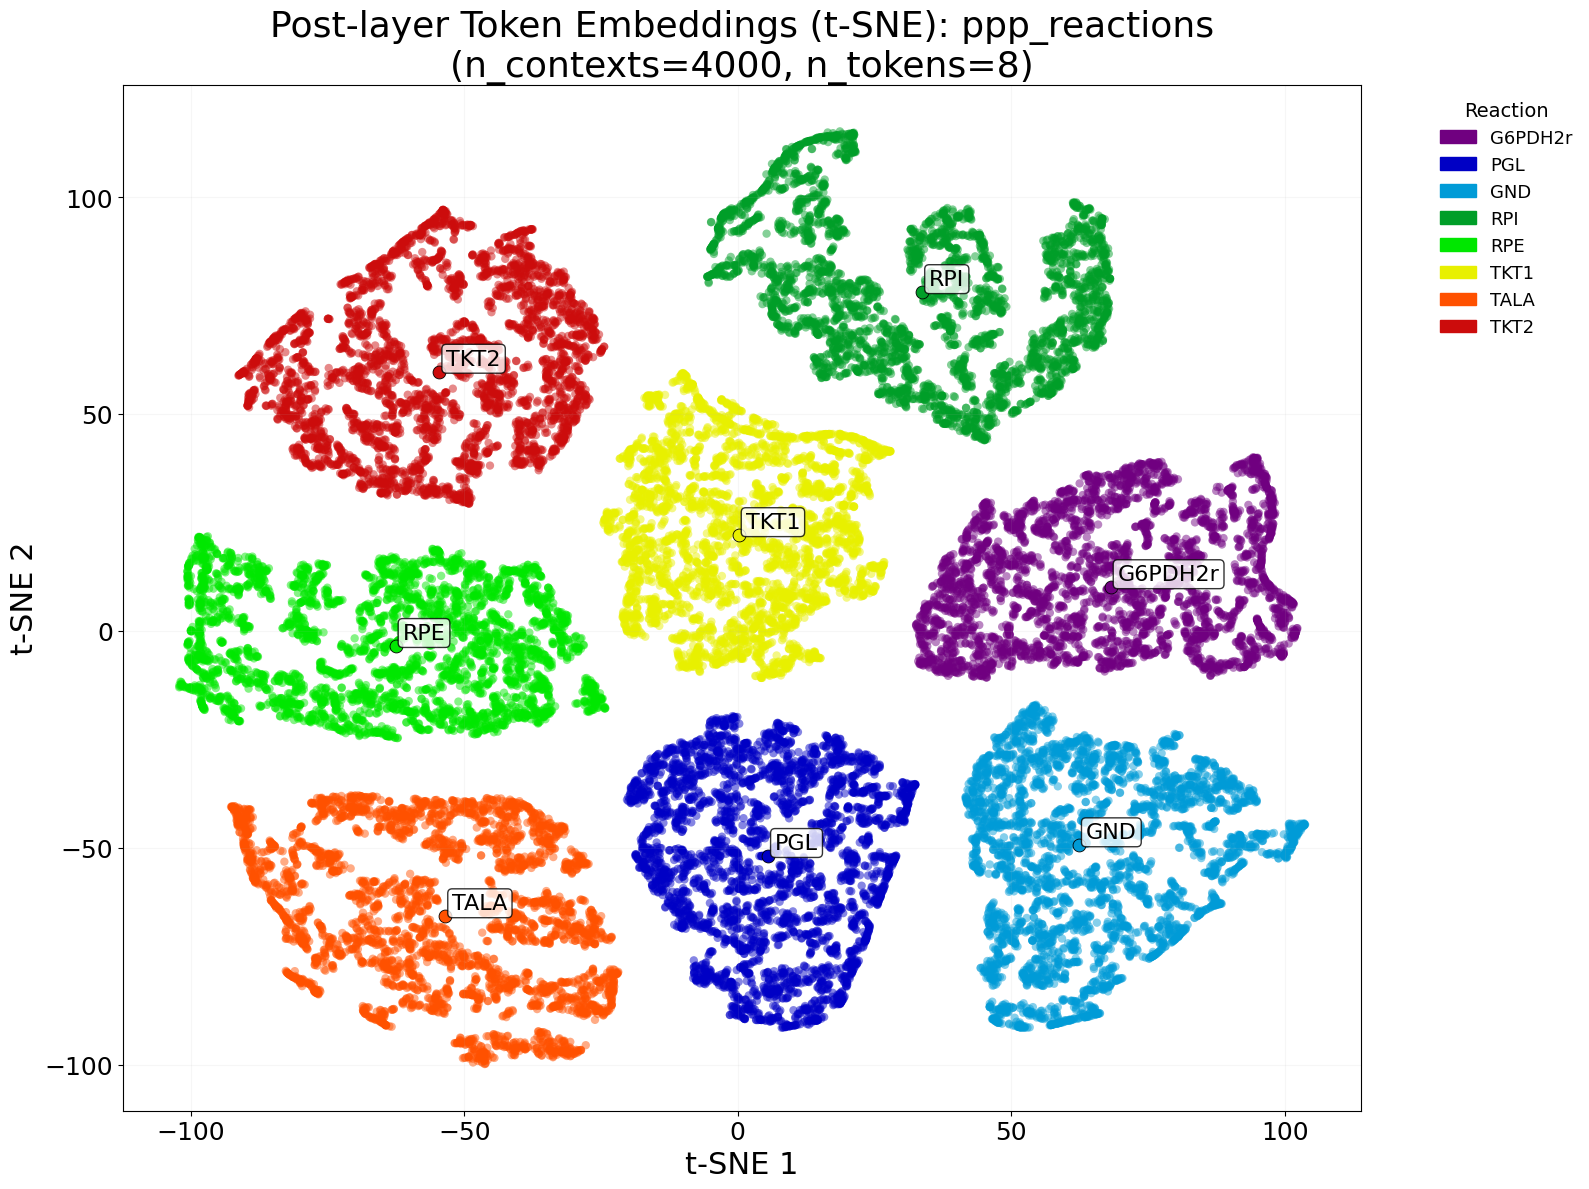

In [39]:
save_path = f"{pic_dir}/{model_name}_tsne_ppp_reactions"

plot_reaction_subset_tsne(
    model,
    outputs,
    X_test,
    ppp_reactions,
    subset_name="ppp_reactions",
    n_samples=4000,
    perplexity=40.0,
    annotate=True,
    annotate_fontsize=16,
    save_path=save_path,
)


Plot saved to ./pics/2026-07-09/AMN_500k_d256_h8_l3_ff1024/AMN_500k_d256_h8_l3_ff1024_tsne_tca_reactions_rainbow


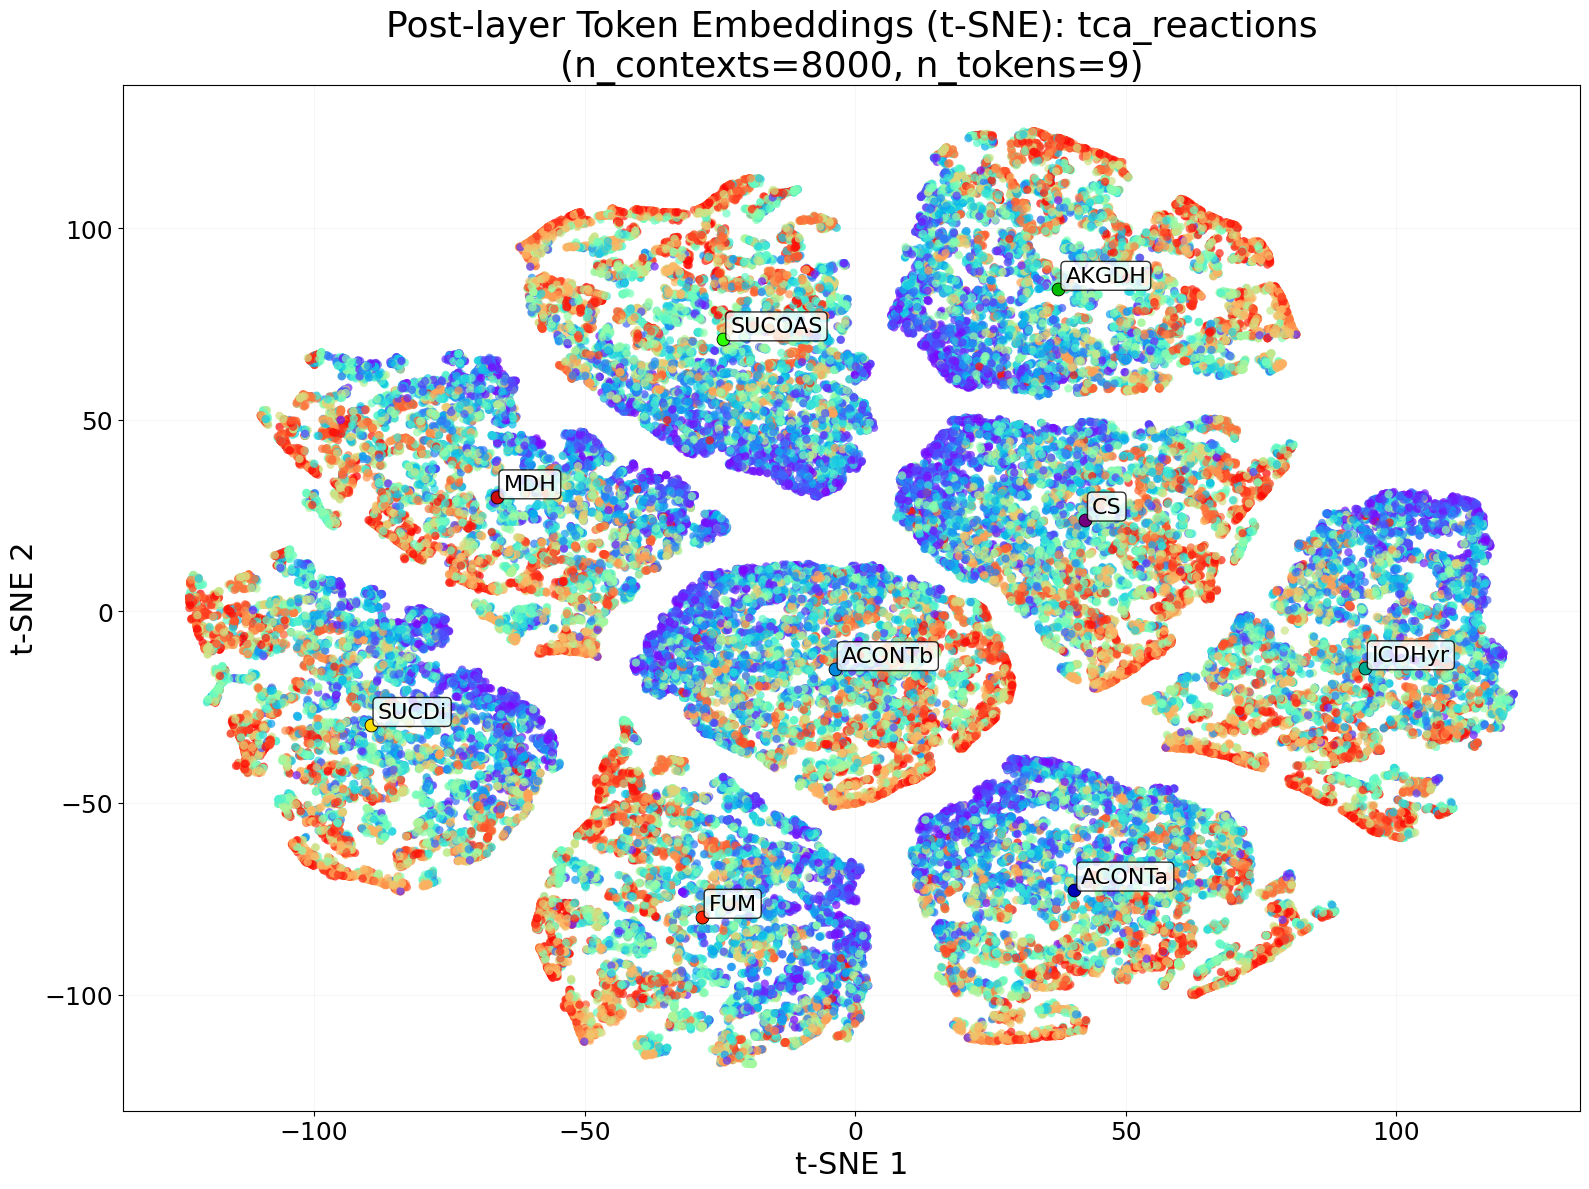

In [40]:
save_path = f"{pic_dir}/{model_name}_tsne_tca_reactions_rainbow"

plot_reaction_subset_tsne(
    model,
    outputs,
    X_test,
    tca_reactions,
    subset_name="tca_reactions",
    n_samples=8000,
    perplexity=40.0,
    annotate=True,
    annotate_fontsize=16,
    sample_color_mode="rainbow",
    save_path=save_path,
)


Pre-embedding points plotted: 7
Plot saved to ./pics/2026-07-09/AMN_500k_d256_h8_l3_ff1024/AMN_500k_d256_h8_l3_ff1024_tsne_fermentation_reactions_gray


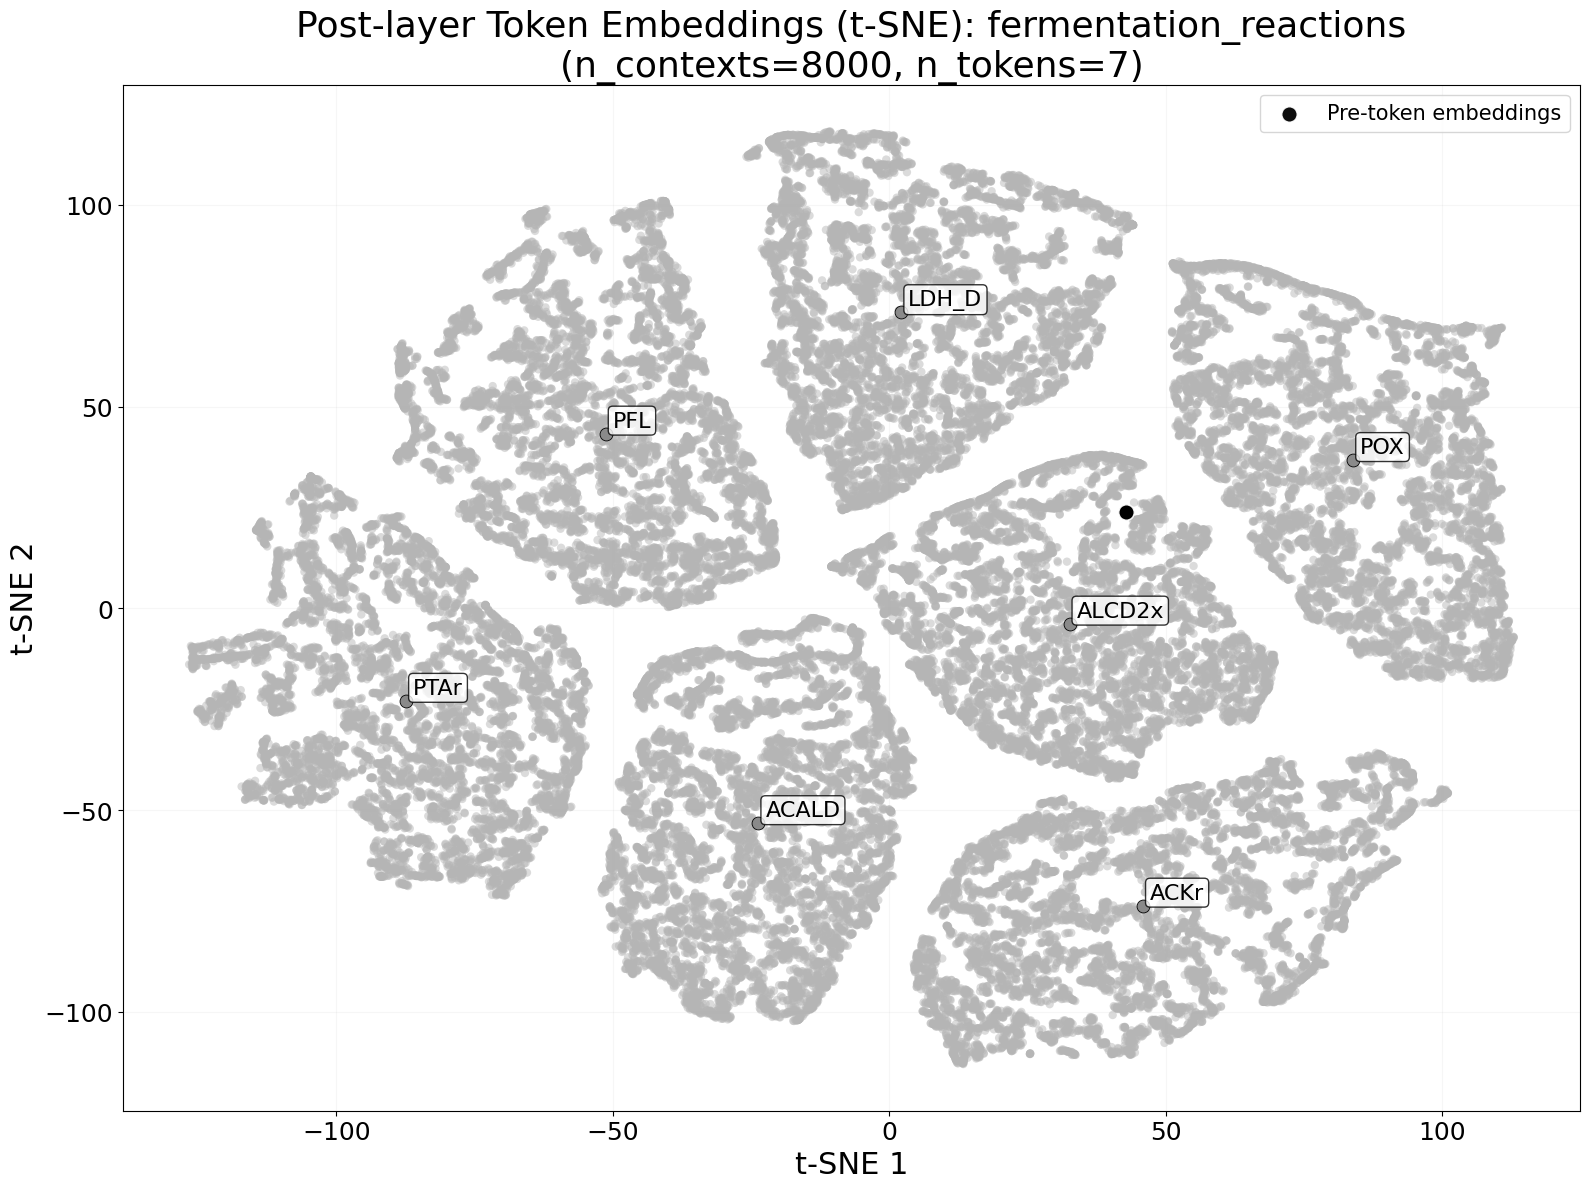

In [41]:
save_path = f"{pic_dir}/{model_name}_tsne_fermentation_reactions_gray"

plot_reaction_subset_tsne(
    model,
    outputs,
    X_test,
    fermentation_reactions,
    subset_name="fermentation_reactions",
    n_samples=8000,
    perplexity=40.0,
    annotate=True,
    annotate_fontsize=16,
    sample_color_mode="gray",
    show_pre_embeddings=True,
    save_path=save_path,
)


### Reservoir Computing on Experimental Data (Frozen FluxTransformer + Prior Dense Net)


In [53]:
from torch.utils.data import TensorDataset, DataLoader

EXP_PATH = "./AMN_data/iML1515_EXP.csv"
GROWTH_TARGET_COL = "GR_AVG"
BIOMASS_TOKEN = "BIOMASS_Ec_iML1515_core_75p37M_flux"

exp_df = pd.read_csv(EXP_PATH).fillna(0.0)

# Normalize experimental column names to match model input names.
# Example: EX_pi_e_i -> EX_pi_e
normalized_cols = {c: c[:-2] if c.endswith("_i") else c for c in exp_df.columns}
exp_df = exp_df.rename(columns=normalized_cols)

OPTIONAL_ABSENT_INPUT_DEFAULTS = {
    # Shared AMN/MINN checkpoints include these MINN-context inputs, but
    # Faure experimental media do not contain glucose or ethanol columns.
    "EX_glc__D_e": 0.0,
    "EX_etoh_e": 0.0,
}
missing_inputs = [c for c in inputs if c not in exp_df.columns]
unknown_missing_inputs = [c for c in missing_inputs if c not in OPTIONAL_ABSENT_INPUT_DEFAULTS]
if unknown_missing_inputs:
    raise ValueError(f"Missing expected input columns in experimental data: {unknown_missing_inputs}")
for c in missing_inputs:
    exp_df[c] = float(OPTIONAL_ABSENT_INPUT_DEFAULTS[c])
if missing_inputs:
    print("Filled optional absent experimental inputs with defaults:")
    print({c: OPTIONAL_ABSENT_INPUT_DEFAULTS[c] for c in missing_inputs})
if GROWTH_TARGET_COL not in exp_df.columns:
    raise ValueError(f"Missing growth target column: {GROWTH_TARGET_COL}")
if BIOMASS_TOKEN not in outputs:
    raise ValueError(f"Biomass token not found in outputs: {BIOMASS_TOKEN}")

# Only variable media are learned by the front ANN, fixed media stay constant.
TRAINABLE_EXTRA_INPUTS = {"EX_o2_e"}  # force oxygen to be trainable with variable carbons
variable_input_cols = [c for c in inputs if (exp_df[c].nunique(dropna=False) > 1) or (c in TRAINABLE_EXTRA_INPUTS)]
fixed_input_cols = [c for c in inputs if c not in variable_input_cols]

if len(variable_input_cols) == 0:
    raise ValueError("No variable input columns found in experimental dataset.")

biomass_idx = outputs.index(BIOMASS_TOKEN)

print(f"Experimental samples: {len(exp_df)}")
print(f"Total media inputs: {len(inputs)}")
print(f"Variable media inputs learned by prior ANN: {len(variable_input_cols)}")
print(f"Fixed media inputs kept constant: {len(fixed_input_cols)}")
print(f"Biomass output token index: {biomass_idx}")

var_pos = torch.tensor([inputs.index(c) for c in variable_input_cols], dtype=torch.long, device=device)
fixed_pos = torch.tensor([inputs.index(c) for c in fixed_input_cols], dtype=torch.long, device=device)
token_idx = torch.tensor(input_token_indices, dtype=torch.long, device=device)

X_var = torch.tensor(exp_df[variable_input_cols].to_numpy(dtype=np.float32), dtype=torch.float32, device=device)
y_growth = torch.tensor(exp_df[GROWTH_TARGET_COL].to_numpy(dtype=np.float32), dtype=torch.float32, device=device)

# Convert fixed presence flags (0/1) into physical bounds, aligned with simulation generator.
BASE_DEFAULT_RATE = 10.0
AMINO_RATE = 2.2
FIXED_SPECIAL_RATES = {
    "EX_glyc_e": AMINO_RATE,
}
AMINO_EXCHANGES = {"EX_ala__L_e", "EX_pro__L_e", "EX_thr__L_e", "EX_gly_e"}

def fixed_presence_to_bound(col_name, presence_value):
    if presence_value <= 0:
        return 0.0
    if col_name in FIXED_SPECIAL_RATES:
        return FIXED_SPECIAL_RATES[col_name]
    if col_name in AMINO_EXCHANGES:
        return AMINO_RATE
    return BASE_DEFAULT_RATE

if len(fixed_input_cols) > 0:
    fixed_presence = exp_df[fixed_input_cols].iloc[0].to_numpy(dtype=np.float32)
    fixed_bound_values = np.array(
        [fixed_presence_to_bound(c, v) for c, v in zip(fixed_input_cols, fixed_presence)],
        dtype=np.float32,
    )
    fixed_values = torch.tensor(fixed_bound_values, dtype=torch.float32, device=device)
else:
    fixed_values = torch.empty(0, dtype=torch.float32, device=device)

print("Variable input columns:")
print(variable_input_cols)
print("Fixed input bounds used (derived from presence flags):")
print({c: float(v) for c, v in zip(fixed_input_cols, fixed_values.detach().cpu().numpy())})

Experimental samples: 110
Total media inputs: 38
Variable media inputs learned by prior ANN: 11
Fixed media inputs kept constant: 27
Biomass output token index: 2668
Variable input columns:
['EX_o2_e', 'EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_ac_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e']
Fixed input bounds used (derived from presence flags):
{'EX_pi_e': 10.0, 'EX_co2_e': 10.0, 'EX_fe3_e': 10.0, 'EX_h_e': 10.0, 'EX_mn2_e': 10.0, 'EX_fe2_e': 10.0, 'EX_zn2_e': 10.0, 'EX_mg2_e': 10.0, 'EX_ca2_e': 10.0, 'EX_ni2_e': 10.0, 'EX_cu2_e': 10.0, 'EX_sel_e': 10.0, 'EX_cobalt2_e': 10.0, 'EX_h2o_e': 10.0, 'EX_mobd_e': 10.0, 'EX_so4_e': 10.0, 'EX_nh4_e': 10.0, 'EX_k_e': 10.0, 'EX_na1_e': 10.0, 'EX_cl_e': 10.0, 'EX_tungs_e': 10.0, 'EX_slnt_e': 10.0, 'EX_glyc_e': 2.200000047683716, 'EX_ala__L_e': 2.200000047683716, 'EX_pro__L_e': 2.200000047683716, 'EX_thr__L_e': 2.200000047683716, 'EX_gly_e': 2.200000047683716}


In [54]:
class PriorDenseNetwork(nn.Module):
    def __init__(self, in_dim, out_dim, n_hidden=1, hidden_dim=512, activation="relu", out_scale=2.2, dropout=0.25):
        super().__init__()
        if in_dim <= 0 or out_dim <= 0:
            raise ValueError("in_dim and out_dim must be positive.")

        act = nn.ReLU if activation.lower() == "relu" else nn.GELU
        layers = []
        last_dim = in_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(act())
            layers.append(nn.Dropout(dropout))
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, out_dim))
        self.net = nn.Sequential(*layers)
        out_scale_t = torch.as_tensor(out_scale, dtype=torch.float32)
        if out_scale_t.ndim == 0:
            out_scale_t = out_scale_t.repeat(out_dim)
        elif out_scale_t.ndim == 1 and out_scale_t.numel() == out_dim:
            pass
        else:
            raise ValueError(f"out_scale must be scalar or shape ({out_dim},), got {tuple(out_scale_t.shape)}")
        self.register_buffer("out_scale", out_scale_t.view(1, out_dim), persistent=True)

    def forward(self, x):
        # x is binary presence (0/1) for variable carbon sources.
        # Predict bounded uptake rates and force absent sources to zero.
        mask = (x > 0).float()
        raw = self.net(x)
        rates = torch.sigmoid(raw) * self.out_scale
        return mask * rates


In [55]:
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.checkpoint import checkpoint


def compose_full_medium(var_part):
    batch = var_part.size(0)
    full_medium = torch.zeros(batch, len(inputs), dtype=torch.float32, device=var_part.device)
    full_medium[:, var_pos] = var_part
    if fixed_values.numel() > 0:
        full_medium[:, fixed_pos] = fixed_values.unsqueeze(0).expand(batch, -1)
    full_medium = torch.clamp(full_medium, min=0.0)
    return full_medium


def medium_to_reservoir_input(full_medium):
    c = torch.zeros(full_medium.size(0), len(outputs), 1, dtype=torch.float32, device=full_medium.device)
    c[:, token_idx, 0] = full_medium
    return c


def _model_only(inp):
    out, _ = model(inp, output_subset=None)
    return out


def _mean_curve(curves):
    max_len = max(len(c) for c in curves)
    mat = np.full((len(curves), max_len), np.nan, dtype=np.float32)
    for i, c in enumerate(curves):
        arr = np.asarray(c, dtype=np.float32)
        mat[i, :len(arr)] = arr
    return np.nanmean(mat, axis=0).tolist()


def _predict_growth_with_prior(prior_model, X_input, chunk_size):
    pred_parts = []
    for s_idx in range(0, X_input.size(0), chunk_size):
        e_idx = min(s_idx + chunk_size, X_input.size(0))
        xb_val = X_input[s_idx:e_idx]
        pred_var_val = prior_model(xb_val)
        full_medium_val = compose_full_medium(pred_var_val)
        c_val = medium_to_reservoir_input(full_medium_val)
        reservoir_val, _ = model(c_val, output_subset=None)
        pred_parts.append(reservoir_val[:, biomass_idx, -1].detach().cpu())
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return torch.cat(pred_parts, dim=0).numpy()


def train_prior_one_seed(
    seed,
    X_train_var,
    y_train_growth,
    X_val_var,
    y_val_growth,
    train_batch_size,
    val_batch_size,
    run_prefix,
    return_model=False,
):
    set_seed(seed)

    prior_net_seed = PriorDenseNetwork(
        in_dim=len(variable_input_cols),
        out_dim=len(variable_input_cols),
        n_hidden=1,
        hidden_dim=hidden_dim,
        activation="relu",
        out_scale=out_scale_vec,
        dropout=dropout,
    ).to(device)

    optimizer_seed = torch.optim.AdamW(prior_net_seed.parameters(), lr=1e-3, weight_decay=1e-3)
    criterion_seed = nn.HuberLoss(delta=0.03)
    train_loader_seed = DataLoader(
        TensorDataset(X_train_var, y_train_growth),
        batch_size=train_batch_size,
        shuffle=True,
    )

    train_losses_seed = []
    val_losses_seed = []
    best_val_seed = float("inf")
    best_state_seed = None
    best_epoch_seed = 0
    no_improve_seed = 0

    for epoch in range(num_epochs):
        prior_net_seed.train()
        running = 0.0

        for xb_var, yb in train_loader_seed:
            optimizer_seed.zero_grad(set_to_none=True)

            pred_var = prior_net_seed(xb_var)
            full_medium = compose_full_medium(pred_var)
            c_in = medium_to_reservoir_input(full_medium)

            reservoir_out = checkpoint(_model_only, c_in, use_reentrant=False)
            y_pred = reservoir_out[:, biomass_idx, -1]
            loss = criterion_seed(y_pred, yb)

            loss.backward()
            optimizer_seed.step()
            running += loss.item() * xb_var.size(0)

            if device.type == "cuda":
                torch.cuda.empty_cache()

        epoch_train = running / max(1, X_train_var.size(0))
        train_losses_seed.append(epoch_train)

        prior_net_seed.eval()
        with torch.no_grad():
            if device.type == "cuda":
                torch.cuda.empty_cache()

            val_running = 0.0
            val_count = 0
            for s_idx in range(0, X_val_var.size(0), val_batch_size):
                e_idx = min(s_idx + val_batch_size, X_val_var.size(0))
                xb_val = X_val_var[s_idx:e_idx]
                yb_val = y_val_growth[s_idx:e_idx]

                pred_var_val = prior_net_seed(xb_val)
                full_medium_val = compose_full_medium(pred_var_val)
                c_val = medium_to_reservoir_input(full_medium_val)
                reservoir_val, _ = model(c_val, output_subset=None)
                y_val_pred = reservoir_val[:, biomass_idx, -1]

                batch_loss = criterion_seed(y_val_pred, yb_val)
                val_running += batch_loss.item() * xb_val.size(0)
                val_count += xb_val.size(0)

                if device.type == "cuda":
                    torch.cuda.empty_cache()

            epoch_val = val_running / max(1, val_count)
            val_losses_seed.append(epoch_val)

        if epoch_val < best_val_seed:
            best_val_seed = epoch_val
            best_state_seed = deepcopy(prior_net_seed.state_dict())
            best_epoch_seed = epoch + 1
            no_improve_seed = 0
        else:
            no_improve_seed += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"{run_prefix} seed={seed} | Epoch {epoch+1:>3}/{num_epochs} | "
                f"train_huber={epoch_train:.6f} | val_huber={epoch_val:.6f} | no_improve={no_improve_seed}"
            )

        if no_improve_seed >= patience:
            print(
                f"{run_prefix} seed={seed} early stop at epoch {epoch+1} "
                f"(best_epoch={best_epoch_seed}, best_val={best_val_seed:.6f})"
            )
            break

    if best_state_seed is None:
        best_state_seed = deepcopy(prior_net_seed.state_dict())

    prior_net_seed.load_state_dict(best_state_seed)
    prior_net_seed.eval()

    with torch.no_grad():
        y_val_pred_seed = _predict_growth_with_prior(prior_net_seed, X_val_var, val_batch_size)

    result = {
        "seed": int(seed),
        "best_val": float(best_val_seed),
        "best_epoch": int(best_epoch_seed),
        "train_losses": train_losses_seed,
        "val_losses": val_losses_seed,
        "y_val_pred": y_val_pred_seed,
        "train_batch_used": int(train_batch_size),
        "val_batch_used": int(val_batch_size),
    }

    if return_model:
        result["model"] = prior_net_seed
    else:
        del prior_net_seed

    del optimizer_seed, train_loader_seed
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return result


def train_prior_one_seed_with_fallback(
    seed,
    X_train_var,
    y_train_growth,
    X_val_var,
    y_val_growth,
    run_prefix,
    return_model=False,
):
    train_batch_try = max(1, min(batch_size, X_train_var.size(0)))
    val_batch_try = max(1, min(val_batch, X_val_var.size(0)))

    while True:
        try:
            return train_prior_one_seed(
                seed=seed,
                X_train_var=X_train_var,
                y_train_growth=y_train_growth,
                X_val_var=X_val_var,
                y_val_growth=y_val_growth,
                train_batch_size=train_batch_try,
                val_batch_size=val_batch_try,
                run_prefix=run_prefix,
                return_model=return_model,
            )
        except RuntimeError as err:
            err_msg = str(err).lower()
            is_oom = "out of memory" in err_msg
            if device.type == "cuda" and is_oom and train_batch_try > 1:
                print(
                    f"{run_prefix} seed={seed} CUDA OOM at batch_size={train_batch_try}; "
                    "retrying with batch_size=1."
                )
                train_batch_try = 1
                val_batch_try = 1
                torch.cuda.empty_cache()
                continue
            raise


# Freeze FluxTransformer parameters and keep deterministic behavior.
for p in model.parameters():
    p.requires_grad = False
model.eval()

set_seed(10)
n_samples = X_var.size(0)
if n_samples < 10:
    raise ValueError("Need at least 10 samples for 10-fold stratified validation.")

CARBON_SOURCE_COLS = [
    "EX_rib__D_e",
    "EX_malt_e",
    "EX_melib_e",
    "EX_tre_e",
    "EX_fru_e",
    "EX_gal_e",
    "EX_ac_e",
    "EX_lac__D_e",
    "EX_succ_e",
    "EX_pyr_e",
]
missing_carbon_cols = [c for c in CARBON_SOURCE_COLS if c not in exp_df.columns]
if missing_carbon_cols:
    raise ValueError(f"Missing required carbon source columns for stratification: {missing_carbon_cols}")

stratify_y = exp_df[CARBON_SOURCE_COLS].gt(0).sum(axis=1).to_numpy(dtype=np.int64)
if np.any((stratify_y < 1) | (stratify_y > 4)):
    raise ValueError("Experimental strata must be carbon-source counts in {1,2,3,4}.")

exp110_df = pd.read_csv("AMN_data/EXP110.csv")
if "GR_STD" not in exp110_df.columns:
    raise ValueError("EXP110.csv must contain GR_STD column.")
y_std_all = exp110_df["GR_STD"].to_numpy(dtype=np.float32)
if y_std_all.shape[0] != n_samples:
    raise ValueError("EXP110.csv GR_STD length must match number of samples used in training.")

n_splits = 10
cv_split_seeds = [10, 11, 12]
prior_train_seed = 10

strata_counts = np.bincount(stratify_y, minlength=5)[1:5]
if np.min(strata_counts) < n_splits:
    raise ValueError("Each carbon-source-count stratum must have at least 10 samples for 10-fold stratified CV.")
print("Stratification counts (1,2,3,4 carbons):", strata_counts.tolist())

num_epochs = 100
hidden_dim = 512
dropout = 0.0
batch_size = 1
val_batch = 2
patience = 15
ensemble_seeds = [10, 11, 12]  # final full-data ensemble fit only

out_scale_vec = np.array([10.0 if c == "EX_o2_e" else 2.2 for c in variable_input_cols], dtype=np.float32)
print(
    f"Training config | epochs={num_epochs} | patience={patience} | base_batch={batch_size} | "
    f"cv_split_seeds={cv_split_seeds} | prior_train_seed={prior_train_seed}"
)

fold_summaries = []
oof_true_parts = []
oof_pred_parts = []
oof_fold_parts = []
oof_std_parts = []
oof_idx_parts = []

for split_seed in cv_split_seeds:
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=split_seed)

    for fold_local_id, (tr_np, va_np) in enumerate(skf.split(np.arange(n_samples), stratify_y), start=1):
        train_idx = torch.tensor(tr_np, dtype=torch.long, device=device)
        val_idx = torch.tensor(va_np, dtype=torch.long, device=device)

        X_train_var = X_var[train_idx]
        y_train_growth = y_growth[train_idx]
        X_val_var = X_var[val_idx]
        y_val_growth = y_growth[val_idx]

        seed_result = train_prior_one_seed_with_fallback(
            seed=prior_train_seed,
            X_train_var=X_train_var,
            y_train_growth=y_train_growth,
            X_val_var=X_val_var,
            y_val_growth=y_val_growth,
            run_prefix=f"CV seed {split_seed} fold {fold_local_id}/{n_splits}",
            return_model=False,
        )

        y_val_true_fold = y_val_growth.detach().cpu().numpy()
        y_val_pred_fold = seed_result["y_val_pred"]

        fold_r2 = r2_score(y_val_true_fold, y_val_pred_fold)
        fold_mae = mean_absolute_error(y_val_true_fold, y_val_pred_fold)
        fold_mse = float(np.mean((y_val_true_fold - y_val_pred_fold) ** 2))

        oof_true_parts.append(y_val_true_fold)
        oof_pred_parts.append(y_val_pred_fold)
        oof_fold_parts.append(np.full(y_val_true_fold.shape[0], fold_local_id, dtype=np.int32))
        oof_std_parts.append(y_std_all[va_np])
        oof_idx_parts.append(va_np.astype(np.int32))

        fold_summaries.append({
            "cv_seed": int(split_seed),
            "fold": int(fold_local_id),
            "best_val": float(seed_result["best_val"]),
            "best_epoch": int(seed_result["best_epoch"]),
            "train_losses": seed_result["train_losses"],
            "val_losses": seed_result["val_losses"],
            "r2": float(fold_r2),
            "mae": float(fold_mae),
            "mse": float(fold_mse),
            "y_val_true": y_val_true_fold.tolist(),
            "y_val_pred": y_val_pred_fold.tolist(),
            "train_seed": int(prior_train_seed),
            "train_batch_used": int(seed_result["train_batch_used"]),
            "val_batch_used": int(seed_result["val_batch_used"]),
        })

        print(
            f"cv_seed={split_seed} fold={fold_local_id:>2d} | "
            f"R2={fold_r2:.4f} | MAE={fold_mae:.6f} | MSE={fold_mse:.6f} | "
            f"best_val={seed_result['best_val']:.6f}"
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()

oof_true_cv_raw = np.concatenate(oof_true_parts, axis=0)
oof_pred_cv_raw = np.concatenate(oof_pred_parts, axis=0)
oof_fold_cv_raw = np.concatenate(oof_fold_parts, axis=0)
oof_std_cv_raw = np.concatenate(oof_std_parts, axis=0)
oof_idx_cv_raw = np.concatenate(oof_idx_parts, axis=0)

# Aggregate repeated-CV predictions so each experimental sample contributes one OOF dot.
pred_sum = np.zeros(n_samples, dtype=np.float64)
pred_sumsq = np.zeros(n_samples, dtype=np.float64)
pred_count = np.zeros(n_samples, dtype=np.int32)
oof_true_per_sample = np.full(n_samples, np.nan, dtype=np.float32)
oof_std_per_sample = np.full(n_samples, np.nan, dtype=np.float32)
oof_fold_per_sample = np.full(n_samples, -1, dtype=np.int32)

for idx_i, y_t, y_p, f_i, y_s in zip(oof_idx_cv_raw, oof_true_cv_raw, oof_pred_cv_raw, oof_fold_cv_raw, oof_std_cv_raw):
    idx_i = int(idx_i)
    pred_sum[idx_i] += float(y_p)
    pred_sumsq[idx_i] += float(y_p) ** 2
    pred_count[idx_i] += 1
    if np.isnan(oof_true_per_sample[idx_i]):
        oof_true_per_sample[idx_i] = float(y_t)
        oof_std_per_sample[idx_i] = float(y_s)
    if oof_fold_per_sample[idx_i] < 0:
        oof_fold_per_sample[idx_i] = int(f_i)

expected_count = len(cv_split_seeds)
if not np.all(pred_count == expected_count):
    uniq_counts, uniq_freq = np.unique(pred_count, return_counts=True)
    raise ValueError(
        f"Repeated-CV aggregation error: expected each sample to have {expected_count} predictions, "
        f"but got counts {dict(zip(uniq_counts.tolist(), uniq_freq.tolist()))}."
    )

oof_pred_mean = pred_sum / pred_count
oof_pred_cv = oof_pred_mean.astype(np.float32)
oof_pred_seed_var_cv = (pred_sumsq - pred_count * oof_pred_mean ** 2) / np.maximum(1, pred_count - 1)
oof_pred_seed_std_cv = np.sqrt(np.maximum(0.0, oof_pred_seed_var_cv)).astype(np.float32)
oof_true_cv = oof_true_per_sample.astype(np.float32)
oof_std_cv = oof_std_per_sample.astype(np.float32)
oof_fold_cv = oof_fold_per_sample.astype(np.int32)

best_vals = np.array([f["best_val"] for f in fold_summaries], dtype=np.float32)
cv_r2 = np.array([f["r2"] for f in fold_summaries], dtype=np.float32)
cv_mae = np.array([f["mae"] for f in fold_summaries], dtype=np.float32)
cv_mse = np.array([f["mse"] for f in fold_summaries], dtype=np.float32)
cv_r2_mean, cv_r2_std = float(cv_r2.mean()), float(cv_r2.std(ddof=0))
cv_mae_mean, cv_mae_std = float(cv_mae.mean()), float(cv_mae.std(ddof=0))
cv_mse_mean, cv_mse_std = float(cv_mse.mean()), float(cv_mse.std(ddof=0))
print("Repeated stratified K-fold summary")
print(
    f"n_splits={n_splits} | n_repeat_seeds={len(cv_split_seeds)} | total_fits={len(fold_summaries)} | "
    f"mean_best_val={best_vals.mean():.6f} | std_best_val={best_vals.std(ddof=0):.6f}"
)
print(f"CV R2 : {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
print(f"CV MAE: {cv_mae_mean:.6f} +/- {cv_mae_std:.6f}")
print(f"CV MSE: {cv_mse_mean:.6f} +/- {cv_mse_std:.6f}")
for f in fold_summaries:
    print(
        f"cv_seed={f['cv_seed']} fold={f['fold']} best_epoch~{f['best_epoch']} "
        f"best_val={f['best_val']:.6f} r2={f['r2']:.4f} mae={f['mae']:.6f} mse={f['mse']:.6f}"
    )

# Train final prior-net ensemble with an internal stratified split and early stopping.
full_train_np, full_val_np = train_test_split(
    np.arange(n_samples),
    test_size=0.1,
    random_state=10,
    stratify=stratify_y,
    shuffle=True,
)
full_train_idx = torch.tensor(full_train_np, dtype=torch.long, device=device)
full_val_idx = torch.tensor(full_val_np, dtype=torch.long, device=device)

X_full_train_var = X_var[full_train_idx]
y_full_train_growth = y_growth[full_train_idx]
X_full_val_var = X_var[full_val_idx]
y_full_val_growth = y_growth[full_val_idx]

full_seed_results = []
for seed in ensemble_seeds:
    seed_result = train_prior_one_seed_with_fallback(
        seed=seed,
        X_train_var=X_full_train_var,
        y_train_growth=y_full_train_growth,
        X_val_var=X_full_val_var,
        y_val_growth=y_full_val_growth,
        run_prefix="Full fit",
        return_model=True,
    )
    full_seed_results.append(seed_result)

prior_net_ensemble = [r["model"] for r in full_seed_results]
for net in prior_net_ensemble:
    net.eval()

# Backward-compatible handle for downstream cells that expect a single model object.
prior_net = prior_net_ensemble[0]


def prior_net_predict_var_ensemble(X_input, infer_batch=None, model_list=None):
    models = prior_net_ensemble if model_list is None else model_list
    if len(models) == 0:
        raise ValueError("No models available in prior_net_ensemble.")

    if infer_batch is None:
        infer_batch = max(1, min(val_batch, X_input.size(0)))

    pred_parts = []
    with torch.no_grad():
        for s_idx in range(0, X_input.size(0), infer_batch):
            e_idx = min(s_idx + infer_batch, X_input.size(0))
            xb = X_input[s_idx:e_idx]
            pred_sum = torch.zeros(xb.size(0), len(variable_input_cols), dtype=torch.float32, device=xb.device)
            for net in models:
                pred_sum += net(xb)
            pred_parts.append(pred_sum / float(len(models)))
            if device.type == "cuda":
                torch.cuda.empty_cache()

    return torch.cat(pred_parts, dim=0)


train_losses_prior = _mean_curve([r["train_losses"] for r in full_seed_results])
val_losses_prior = _mean_curve([r["val_losses"] for r in full_seed_results])
full_best_val = float(np.mean([r["best_val"] for r in full_seed_results]))
full_best_epoch = int(round(np.mean([r["best_epoch"] for r in full_seed_results])))

full_seed_summaries = [
    {
        "seed": int(r["seed"]),
        "best_val": float(r["best_val"]),
        "best_epoch": int(r["best_epoch"]),
        "train_batch_used": int(r["train_batch_used"]),
        "val_batch_used": int(r["val_batch_used"]),
    }
    for r in full_seed_results
]

print("Final ensemble summary")
print(
    f"seeds={ensemble_seeds} | mean_best_val={full_best_val:.6f} | "
    f"std_best_val={np.std([r['best_val'] for r in full_seed_results], ddof=0):.6f} | "
    f"mean_best_epoch={full_best_epoch}"
)
for s in full_seed_summaries:
    print(
        f"seed={s['seed']} best_epoch={s['best_epoch']} best_val={s['best_val']:.6f} "
        f"train_batch={s['train_batch_used']} val_batch={s['val_batch_used']}"
    )



Stratification counts (1,2,3,4 carbons): [10, 20, 40, 40]
Training config | epochs=100 | patience=15 | base_batch=1 | cv_split_seeds=[10, 11, 12] | prior_train_seed=10
CV seed 10 fold 1/10 seed=10 | Epoch   1/100 | train_huber=0.000877 | val_huber=0.000327 | no_improve=0
CV seed 10 fold 1/10 seed=10 | Epoch  10/100 | train_huber=0.000181 | val_huber=0.000265 | no_improve=3
CV seed 10 fold 1/10 seed=10 | Epoch  20/100 | train_huber=0.000090 | val_huber=0.000328 | no_improve=13
CV seed 10 fold 1/10 seed=10 early stop at epoch 22 (best_epoch=7, best_val=0.000110)
cv_seed=10 fold= 1 | R2=0.9777 | MAE=0.012270 | MSE=0.000220 | best_val=0.000110
CV seed 10 fold 2/10 seed=10 | Epoch   1/100 | train_huber=0.000837 | val_huber=0.000728 | no_improve=0
CV seed 10 fold 2/10 seed=10 | Epoch  10/100 | train_huber=0.000170 | val_huber=0.000229 | no_improve=0
CV seed 10 fold 2/10 seed=10 | Epoch  20/100 | train_huber=0.000032 | val_huber=0.000322 | no_improve=5
CV seed 10 fold 2/10 seed=10 | Epoch  30

In-sample prior model fit on full experimental set (ensemble, n=3)
R2:  0.9774
MAE: 0.008032
MSE: 0.000160

Cross-validated performance:
R2 : 0.8224 +/- 0.1545
MAE: 0.024563 +/- 0.006525
MSE: 0.000985 +/- 0.000447


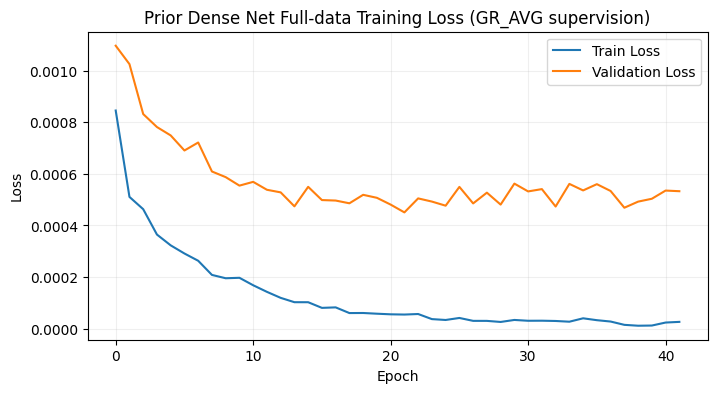

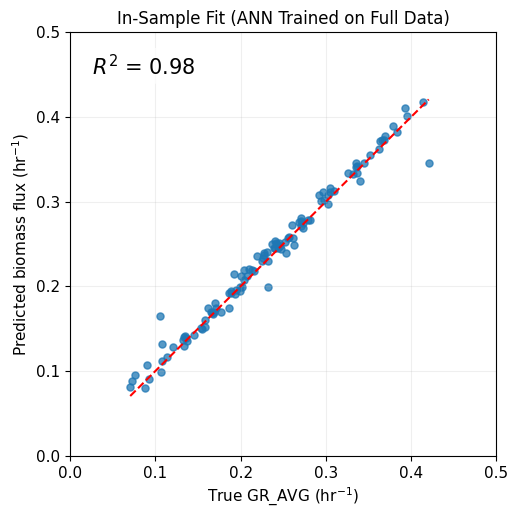

Saved figure to: C:\Users\truok\Documents\metabolic-NN\insights\thesis\iML1515_insample_fit.png


In [56]:
with torch.no_grad():
    pred_var_all = prior_net_predict_var_ensemble(X_var, infer_batch=1)
    full_medium_all = compose_full_medium(pred_var_all)

    infer_batch = 1
    pred_parts = []
    for s_idx in range(0, full_medium_all.size(0), infer_batch):
        e_idx = min(s_idx + infer_batch, full_medium_all.size(0))
        c_all = medium_to_reservoir_input(full_medium_all[s_idx:e_idx])
        reservoir_all, _ = model(c_all, output_subset=None)
        pred_parts.append(reservoir_all[:, biomass_idx, -1].detach().cpu())
        if device.type == "cuda":
            torch.cuda.empty_cache()

    y_pred_all = torch.cat(pred_parts, dim=0).numpy()

y_true_all = y_growth.detach().cpu().numpy()
r2_growth = r2_score(y_true_all, y_pred_all)
mae_growth = mean_absolute_error(y_true_all, y_pred_all)
mse_growth = np.mean((y_true_all - y_pred_all) ** 2)

print(f"In-sample prior model fit on full experimental set (ensemble, n={len(prior_net_ensemble)})")
print(f"R2:  {r2_growth:.4f}")
print(f"MAE: {mae_growth:.6f}")
print(f"MSE: {mse_growth:.6f}")
if "cv_r2_mean" in globals():
    print("\nCross-validated performance:")
    print(f"R2 : {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
    print(f"MAE: {cv_mae_mean:.6f} +/- {cv_mae_std:.6f}")
    print(f"MSE: {cv_mse_mean:.6f} +/- {cv_mse_std:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses_prior, label="Train Loss")
if len(val_losses_prior) > 0:
    plt.plot(val_losses_prior, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Prior Dense Net Full-data Training Loss (GR_AVG supervision)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true_all, y_pred_all, alpha=0.75, s=26)
line_min_v = float(max(0.0, min(y_true_all.min(), y_pred_all.min())))
line_max_v = float(min(0.5, max(y_true_all.max(), y_pred_all.max())))
plt.plot([line_min_v, line_max_v], [line_min_v, line_max_v], "r--", lw=1.5, label="Ideal")
plt.xlabel(r"True GR_AVG (hr$^{-1}$)", fontsize=11)
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)", fontsize=11)
plt.title("In-Sample Fit (ANN Trained on Full Data)")
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, rf"$R^2$ = {r2_growth:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=15,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
#plt.legend()
plt.grid(alpha=0.2)

from pathlib import Path
out_dir = Path("./insights/thesis")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "iML1515_insample_fit.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path.resolve()}")


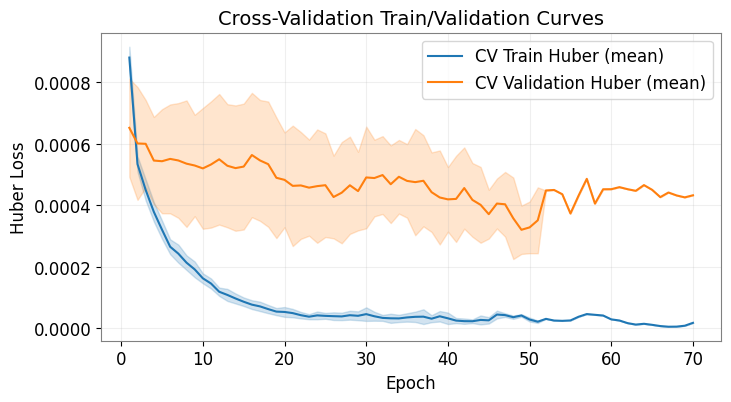


Per-fold CV metrics:
cv_seed=10 fold= 1 | R2=0.9777 | MAE=0.012270 | MSE=0.000220
cv_seed=10 fold= 2 | R2=0.9636 | MAE=0.017425 | MSE=0.000391
cv_seed=10 fold= 3 | R2=0.9528 | MAE=0.014075 | MSE=0.000325
cv_seed=10 fold= 4 | R2=0.8985 | MAE=0.029956 | MSE=0.001261
cv_seed=10 fold= 5 | R2=0.6810 | MAE=0.023322 | MSE=0.001119
cv_seed=10 fold= 6 | R2=0.8304 | MAE=0.021519 | MSE=0.000730
cv_seed=10 fold= 7 | R2=0.7040 | MAE=0.031877 | MSE=0.001424
cv_seed=10 fold= 8 | R2=0.7694 | MAE=0.033257 | MSE=0.001308
cv_seed=10 fold= 9 | R2=0.7341 | MAE=0.023468 | MSE=0.000835
cv_seed=10 fold=10 | R2=0.7953 | MAE=0.031810 | MSE=0.001553
cv_seed=11 fold= 1 | R2=0.9263 | MAE=0.015200 | MSE=0.000341
cv_seed=11 fold= 2 | R2=0.9071 | MAE=0.020694 | MSE=0.000845
cv_seed=11 fold= 3 | R2=0.8334 | MAE=0.023239 | MSE=0.001013
cv_seed=11 fold= 4 | R2=0.8834 | MAE=0.028166 | MSE=0.000928
cv_seed=11 fold= 5 | R2=0.8515 | MAE=0.027230 | MSE=0.001257
cv_seed=11 fold= 6 | R2=0.9478 | MAE=0.015254 | MSE=0.000276
cv

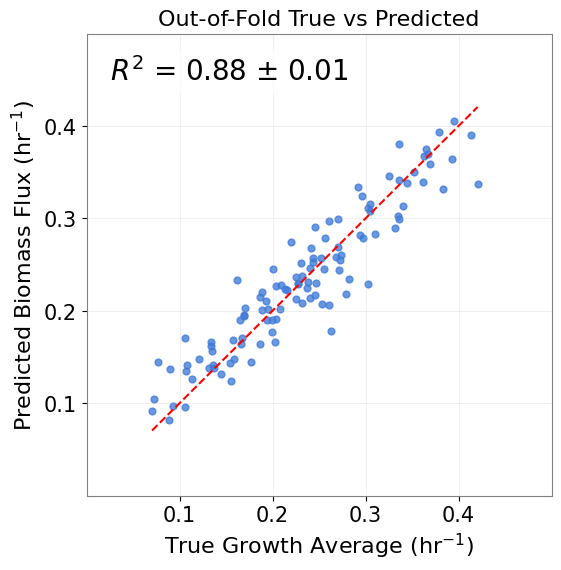

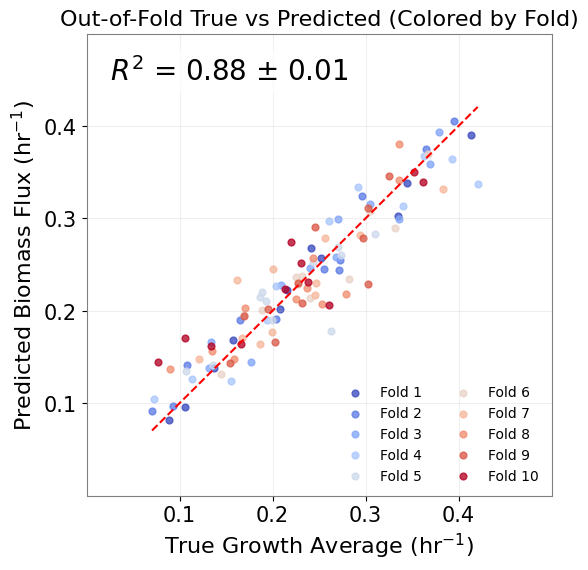

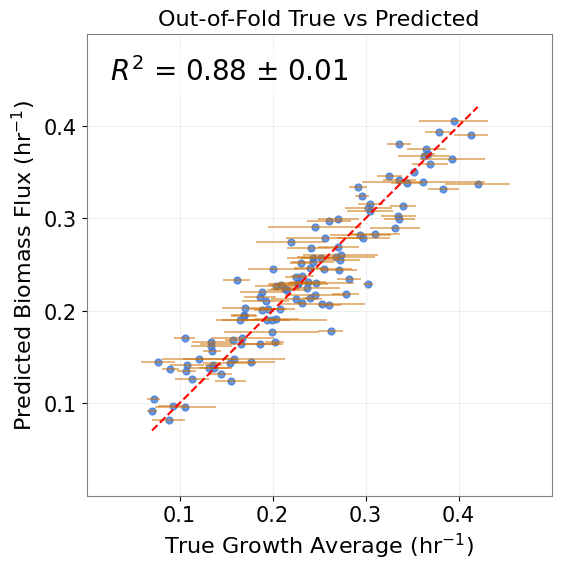

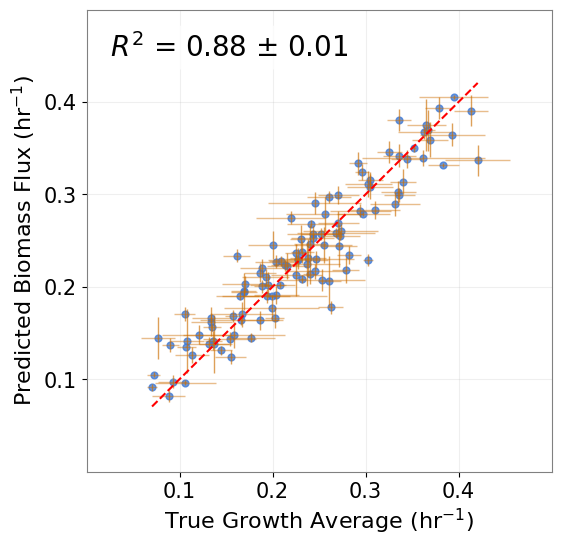

In [57]:
# CV diagnostics: mean train/validation curves, OOF scatter, and best-fold scatter
train_curves_cv = [np.array(f["train_losses"], dtype=np.float32) for f in fold_summaries]
val_curves_cv = [np.array(f["val_losses"], dtype=np.float32) for f in fold_summaries]

max_len_cv = max(len(c) for c in train_curves_cv)
train_mat_cv = np.full((len(train_curves_cv), max_len_cv), np.nan, dtype=np.float32)
val_mat_cv = np.full((len(val_curves_cv), max_len_cv), np.nan, dtype=np.float32)

for i, c in enumerate(train_curves_cv):
    train_mat_cv[i, :len(c)] = c
for i, c in enumerate(val_curves_cv):
    val_mat_cv[i, :len(c)] = c

epochs_cv = np.arange(1, max_len_cv + 1)
train_mean_cv = np.nanmean(train_mat_cv, axis=0)
train_std_cv = np.nanstd(train_mat_cv, axis=0)
val_mean_cv = np.nanmean(val_mat_cv, axis=0)
val_std_cv = np.nanstd(val_mat_cv, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(epochs_cv, train_mean_cv, label="CV Train Huber (mean)", color="tab:blue")
plt.fill_between(epochs_cv, train_mean_cv - train_std_cv, train_mean_cv + train_std_cv, alpha=0.2, color="tab:blue")
plt.plot(epochs_cv, val_mean_cv, label="CV Validation Huber (mean)", color="tab:orange")
plt.fill_between(epochs_cv, val_mean_cv - val_std_cv, val_mean_cv + val_std_cv, alpha=0.2, color="tab:orange")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Huber Loss", fontsize=12)
plt.title("Cross-Validation Train/Validation Curves", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.show()

# Per-fold metrics
print("\nPer-fold CV metrics:")
for f in fold_summaries:
    print(
        f"cv_seed={f['cv_seed']} fold={f['fold']:>2d} | "
        f"R2={f['r2']:.4f} | MAE={f['mae']:.6f} | MSE={f['mse']:.6f}"
    )

# Pooled OOF metric (aggregated across repeated split seeds)
r2_oof = r2_score(oof_true_cv, oof_pred_cv)
mae_oof = mean_absolute_error(oof_true_cv, oof_pred_cv)
rmse_oof = np.sqrt(np.mean((oof_true_cv - oof_pred_cv) ** 2))
# Std across split seeds: compute pooled OOF metric per seed, then std over seeds.
r2_seed_vals = []
mae_seed_vals = []
rmse_seed_vals = []
for seed_i in cv_split_seeds:
    y_true_seed_parts = []
    y_pred_seed_parts = []
    for f in fold_summaries:
        if f["cv_seed"] == seed_i:
            y_true_seed_parts.append(np.array(f["y_val_true"], dtype=np.float32))
            y_pred_seed_parts.append(np.array(f["y_val_pred"], dtype=np.float32))

    y_true_seed = np.concatenate(y_true_seed_parts, axis=0)
    y_pred_seed = np.concatenate(y_pred_seed_parts, axis=0)
    if y_true_seed.shape[0] != n_samples:
        raise ValueError(
            f"Expected {n_samples} pooled OOF samples for cv_seed={seed_i}, got {y_true_seed.shape[0]}."
        )

    r2_seed_vals.append(r2_score(y_true_seed, y_pred_seed))
    mae_seed_vals.append(mean_absolute_error(y_true_seed, y_pred_seed))
    rmse_seed_vals.append(np.sqrt(np.mean((y_true_seed - y_pred_seed) ** 2)))

r2_seed_vals = np.array(r2_seed_vals, dtype=np.float32)
mae_seed_vals = np.array(mae_seed_vals, dtype=np.float32)
rmse_seed_vals = np.array(rmse_seed_vals, dtype=np.float32)
r2_oof_std = float(np.std(r2_seed_vals, ddof=0))
mae_oof_std = float(np.std(mae_seed_vals, ddof=0))
rmse_oof_std = float(np.std(rmse_seed_vals, ddof=0))
pred_seed_std_mean = float(np.mean(oof_pred_seed_std_cv))
pred_seed_std_std = float(np.std(oof_pred_seed_std_cv))
print(f"\nAggregated OOF samples: {oof_true_cv.shape[0]}")
print(f"Prediction std across split seeds: mean={pred_seed_std_mean:.6f} +/- {pred_seed_std_std:.6f}")
print(f"\nOut-Of-Fold R2 (pooled): {r2_oof:.4f} +/- {r2_oof_std:.4f}")
print(f"Out-Of-Fold MAE (pooled): {mae_oof:.6f} +/- {mae_oof_std:.6f}")
print(f"Out-Of-Fold RMSE (pooled): {rmse_oof:.6f} +/- {rmse_oof_std:.6f}")

from pathlib import Path
out_dir = Path("./insights/thesis")
out_dir.mkdir(parents=True, exist_ok=True)


# OOF scatter (single color)
plt.figure(figsize=(6, 6))
plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
line_min_cv = float(max(0.0, min(oof_true_cv.min(), oof_pred_cv.min())))
line_max_cv = float(min(0.5, max(oof_true_cv.max(), oof_pred_cv.max())))
plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
plt.title("Out-of-Fold True vs Predicted", fontsize=16)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.savefig(out_dir / "iML1515_oof_true_vs_predicted_all_cv_folds.png", dpi=300, bbox_inches="tight")
plt.show()

# OOF scatter colored by fold
plt.figure(figsize=(6, 6))
cmap = plt.get_cmap("coolwarm", n_splits)
for f in range(1, n_splits + 1):
    m = (oof_fold_cv == f)
    plt.scatter(oof_true_cv[m], oof_pred_cv[m], alpha=0.78, s=24, color=cmap(f - 1), label=f"Fold {f}")
plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
plt.title("Out-of-Fold True vs Predicted (Colored by Fold)", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.legend(ncol=2, fontsize=10, frameon=False)
plt.savefig(out_dir / "iML1515_oof_true_vs_predicted_colored_by_fold.png", dpi=300, bbox_inches="tight")
plt.show()


# Third OOF plot: measured std as horizontal bars around true GR_AVG
plt.figure(figsize=(6, 6))
plt.hlines(
    y=oof_pred_cv,
    xmin=oof_true_cv - oof_std_cv,
    xmax=oof_true_cv + oof_std_cv,
    colors="#CC6E00",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
plt.title("Out-of-Fold True vs Predicted", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.savefig(out_dir / "iML1515_oof_true_vs_predicted_with_std_bars.png", dpi=300, bbox_inches="tight")
plt.show()

# Fourth OOF plot: add vertical bars for prediction std across split seeds
plt.figure(figsize=(6, 6))
plt.hlines(
    y=oof_pred_cv,
    xmin=oof_true_cv - oof_std_cv,
    xmax=oof_true_cv + oof_std_cv,
    colors="#CC6E00",
    alpha=0.45,
    linewidth=1.0,
)
plt.vlines(
    x=oof_true_cv,
    ymin=oof_pred_cv - oof_pred_seed_std_cv,
    ymax=oof_pred_cv + oof_pred_seed_std_cv,
    colors="#CC6E00",
    alpha=0.65,
    linewidth=1.0,
)
plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
#plt.title("Out-of-Fold True vs Predicted", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.savefig(out_dir / "iML1515_oof_true_vs_predicted_with_exp_and_seed_std_bars.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
# Prior-net input/output comparison (variable media only)
with torch.no_grad():
    var_in = X_var.detach().cpu().numpy()                                     # inputs to dense net
    var_out = prior_net_predict_var_ensemble(X_var).detach().cpu().numpy()    # ensemble-mean outputs

in_cols = [f"in::{c}" for c in variable_input_cols]
out_cols = [f"out::{c}" for c in variable_input_cols]

compare_df = pd.DataFrame(
    np.concatenate([var_in, var_out], axis=1),
    columns=in_cols + out_cols
)

display(compare_df.head(10))

,in::EX_o2_e,in::EX_rib__D_e,in::EX_malt_e,in::EX_melib_e,in::EX_tre_e,in::EX_fru_e,in::EX_gal_e,in::EX_ac_e,in::EX_lac__D_e,in::EX_succ_e,...,out::EX_rib__D_e,out::EX_malt_e,out::EX_melib_e,out::EX_tre_e,out::EX_fru_e,out::EX_gal_e,out::EX_ac_e,out::EX_lac__D_e,out::EX_succ_e,out::EX_pyr_e
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,1.448851,0.000000,0.000000,0.000000,0.000000
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,1.310846,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,1.167165,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,1.158113,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.673965
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.698992,0.000000,0.000000,0.000000
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.421168,0.000000,0.000000
7,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.797068,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.26761,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.846397,0.000000


### TabPFN on Experimental Data

In [59]:
from tabpfn import TabPFNRegressor
from tabpfn.model_loading import resolve_model_path, resolve_model_version
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error

reg = TabPFNRegressor()
mp = None if reg.model_path == "auto" else reg.model_path
ver = resolve_model_version(mp).value
print(resolve_model_path(model_path=mp, which="regressor", version=ver)[2][0])

EXP_PATH = "./AMN_data/iML1515_EXP.csv"
GROWTH_TARGET_COL = "GR_AVG"

exp_df_tabpfn = pd.read_csv(EXP_PATH).fillna(0.0)

# Normalize experimental column names to match expected reaction IDs.
# Example: EX_pi_e_i -> EX_pi_e
normalized_cols_tabpfn = {c: c[:-2] if c.endswith("_i") else c for c in exp_df_tabpfn.columns}
exp_df_tabpfn = exp_df_tabpfn.rename(columns=normalized_cols_tabpfn)

if GROWTH_TARGET_COL not in exp_df_tabpfn.columns:
    raise ValueError(f"Missing growth target column: {GROWTH_TARGET_COL}")

CARBON_SOURCE_COLS = [
    "EX_rib__D_e",
    "EX_malt_e",
    "EX_melib_e",
    "EX_tre_e",
    "EX_fru_e",
    "EX_gal_e",
    "EX_ac_e",
    "EX_lac__D_e",
    "EX_succ_e",
    "EX_pyr_e",
]
missing_carbon_cols = [c for c in CARBON_SOURCE_COLS if c not in exp_df_tabpfn.columns]
if missing_carbon_cols:
    raise ValueError(f"Missing required carbon source columns: {missing_carbon_cols}")

# Use only variable carbon sources as TabPFN features.
feature_cols = [c for c in CARBON_SOURCE_COLS if exp_df_tabpfn[c].nunique(dropna=False) > 1]
if len(feature_cols) == 0:
    raise ValueError("No variable carbon-source features found.")

# Safety check: these features are expected to be binary 0/1.
for c in feature_cols:
    vals = set(float(v) for v in pd.Series(exp_df_tabpfn[c]).dropna().unique().tolist())
    if not vals.issubset({0.0, 1.0}):
        raise ValueError(f"Feature {c} is not binary 0/1: {sorted(vals)}")

X_all = exp_df_tabpfn[feature_cols].to_numpy(dtype=np.float32)
y_all = exp_df_tabpfn[GROWTH_TARGET_COL].to_numpy(dtype=np.float32)

exp110_df = pd.read_csv("AMN_data/EXP110.csv")
if "GR_STD" not in exp110_df.columns:
    raise ValueError("EXP110.csv must contain GR_STD column.")
y_std_all = exp110_df["GR_STD"].to_numpy(dtype=np.float32)

stratify_y = exp_df_tabpfn[CARBON_SOURCE_COLS].gt(0).sum(axis=1).to_numpy(dtype=np.int64)
if np.any((stratify_y < 1) | (stratify_y > 4)):
    raise ValueError("Experimental strata must be carbon-source counts in {1,2,3,4}.")

n_samples = X_all.shape[0]
if y_std_all.shape[0] != n_samples:
    raise ValueError("EXP110.csv GR_STD length must match number of samples used in training.")

n_splits = 10
if n_samples < n_splits:
    raise ValueError("Need at least 10 samples for 10-fold stratified CV.")

strata_counts = np.bincount(stratify_y, minlength=5)[1:5]
if np.min(strata_counts) < n_splits:
    raise ValueError("Each carbon-source-count stratum must have at least 10 samples for 10-fold stratified CV.")

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=10)
print("Stratification counts (1,2,3,4 carbons):", strata_counts.tolist())
print("Using variable carbon-source features:", feature_cols)
print(f"Samples: {n_samples}, features: {X_all.shape[1]}")

fold_summaries_tabpfn = []
oof_true_parts_tabpfn = []
oof_pred_parts_tabpfn = []
oof_std_parts_tabpfn = []

for fold_id, (tr_idx, va_idx) in enumerate(skf.split(np.arange(n_samples), stratify_y), start=1):
    X_train, X_val = X_all[tr_idx], X_all[va_idx]
    y_train, y_val = y_all[tr_idx], y_all[va_idx]

    reg = TabPFNRegressor(random_state=10)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_val).astype(np.float32)

    fold_r2 = r2_score(y_val, y_pred)
    fold_mae = mean_absolute_error(y_val, y_pred)
    fold_mse = float(np.mean((y_val - y_pred) ** 2))

    fold_summaries_tabpfn.append({
        "fold": int(fold_id),
        "r2": float(fold_r2),
        "mae": float(fold_mae),
        "mse": float(fold_mse),
    })

    oof_true_parts_tabpfn.append(y_val)
    oof_pred_parts_tabpfn.append(y_pred)
    oof_std_parts_tabpfn.append(y_std_all[va_idx])

    print(f"Fold {fold_id:>2d}/{n_splits} | R2={fold_r2:.4f} | MAE={fold_mae:.6f} | MSE={fold_mse:.6f}")

oof_true_tabpfn = np.concatenate(oof_true_parts_tabpfn)
oof_pred_tabpfn = np.concatenate(oof_pred_parts_tabpfn)
oof_std_tabpfn = np.concatenate(oof_std_parts_tabpfn)

cv_r2_mean_tabpfn = float(np.mean([f["r2"] for f in fold_summaries_tabpfn]))
cv_r2_std_tabpfn = float(np.std([f["r2"] for f in fold_summaries_tabpfn]))
cv_mae_mean_tabpfn = float(np.mean([f["mae"] for f in fold_summaries_tabpfn]))
cv_mae_std_tabpfn = float(np.std([f["mae"] for f in fold_summaries_tabpfn]))
cv_mse_mean_tabpfn = float(np.mean([f["mse"] for f in fold_summaries_tabpfn]))
cv_mse_std_tabpfn = float(np.std([f["mse"] for f in fold_summaries_tabpfn]))

r2_oof_tabpfn = r2_score(oof_true_tabpfn, oof_pred_tabpfn)
mae_oof_tabpfn = mean_absolute_error(oof_true_tabpfn, oof_pred_tabpfn)
rmse_oof_tabpfn = np.sqrt(np.mean((oof_true_tabpfn - oof_pred_tabpfn) ** 2))
print(f"\nOOF pooled, TabPFN | R2: {r2_oof_tabpfn:.4f} | MAE: {mae_oof_tabpfn:.6f} | RMSE: {rmse_oof_tabpfn:.6f}")
print(f"CV mean+/-std | R2: {cv_r2_mean_tabpfn:.4f} +/- {cv_r2_std_tabpfn:.4f}")
print(f"CV mean+/-std | MAE: {cv_mae_mean_tabpfn:.6f} +/- {cv_mae_std_tabpfn:.6f}")
print(f"CV mean+/-std | MSE: {cv_mse_mean_tabpfn:.6f} +/- {cv_mse_std_tabpfn:.6f}")



tabpfn-v3-regressor-v3_default.ckpt
Stratification counts (1,2,3,4 carbons): [10, 20, 40, 40]
Using variable carbon-source features: ['EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_ac_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e']
Samples: 110, features: 10
Fold  1/10 | R2=0.9148 | MAE=0.020393 | MSE=0.000840
Fold  2/10 | R2=0.8866 | MAE=0.031250 | MSE=0.001217
Fold  3/10 | R2=0.8111 | MAE=0.031557 | MSE=0.001303
Fold  4/10 | R2=0.8195 | MAE=0.040908 | MSE=0.002242
Fold  5/10 | R2=0.6013 | MAE=0.023760 | MSE=0.001399
Fold  6/10 | R2=0.7968 | MAE=0.023152 | MSE=0.000874
Fold  7/10 | R2=0.6157 | MAE=0.036042 | MSE=0.001849
Fold  8/10 | R2=0.6545 | MAE=0.036398 | MSE=0.001960
Fold  9/10 | R2=0.6448 | MAE=0.031423 | MSE=0.001115
Fold 10/10 | R2=0.7481 | MAE=0.037537 | MSE=0.001911

OOF pooled, TabPFN | R2: 0.7931 | MAE: 0.031242 | RMSE: 0.038354
CV mean+/-std | R2: 0.7493 +/- 0.1081
CV mean+/-std | MAE: 0.031242 +/- 0.006496
CV mean+/-std | MSE: 0.001471 +/-

R2   : 0.7931
MAE  : 0.0312
RMSE : 0.0384


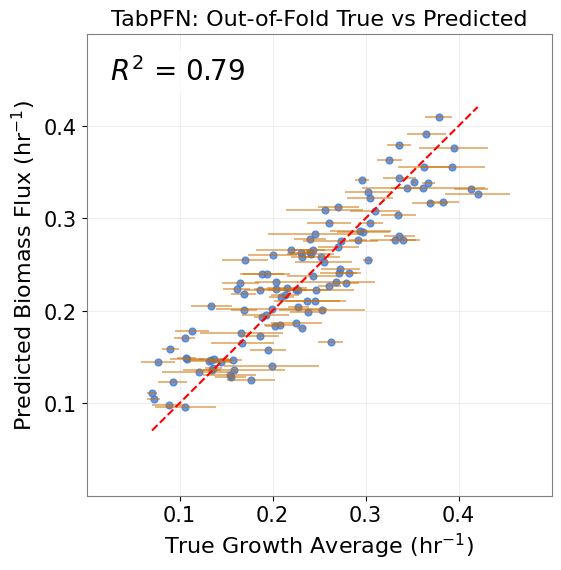

In [60]:
# TabPFN OOF plot with measured std as horizontal bars around true GR_AVG
r2_oof_tabpfn = r2_score(oof_true_tabpfn, oof_pred_tabpfn)
mae_oof_tabpfn = mean_absolute_error(oof_true_tabpfn, oof_pred_tabpfn)
rmse_oof_tabpfn = np.sqrt(np.mean((oof_true_tabpfn - oof_pred_tabpfn) ** 2))

print(f"R2   : {r2_oof_tabpfn:.4f}")
print(f"MAE  : {mae_oof_tabpfn:.4f}")
print(f"RMSE : {rmse_oof_tabpfn:.4f}")

from pathlib import Path
out_dir = Path("./insights/thesis")
out_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 6))
line_min_cv = float(max(0.0, min(oof_true_tabpfn.min(), oof_pred_tabpfn.min())))
line_max_cv = float(min(0.5, max(oof_true_tabpfn.max(), oof_pred_tabpfn.max())))

plt.hlines(
    y=oof_pred_tabpfn,
    xmin=oof_true_tabpfn - oof_std_tabpfn,
    xmax=oof_true_tabpfn + oof_std_tabpfn,
    colors="#CC6E00",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(oof_true_tabpfn, oof_pred_tabpfn, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
plt.title("TabPFN: Out-of-Fold True vs Predicted", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, f"$R^2$ = {r2_oof_tabpfn:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.savefig(out_dir / "iML1515_tabpfn_oof_true_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


TabPFN repeated-CV seed metrics:
cv_seed=10 | R2=0.7931 | MAE=0.031242 | RMSE=0.038354
cv_seed=11 | R2=0.7945 | MAE=0.031379 | RMSE=0.038229
cv_seed=12 | R2=0.8016 | MAE=0.030262 | RMSE=0.037558
TabPFN pooled OOF across split seeds | R2: 0.7964 +/- 0.0037
TabPFN pooled OOF across split seeds | MAE: 0.030961 +/- 0.000498
TabPFN pooled OOF across split seeds | RMSE: 0.038047 +/- 0.000349
TabPFN repeated-CV mean-prediction R2: 0.7993
TabPFN repeated-CV mean-prediction MAE: 0.030717
TabPFN repeated-CV mean-prediction RMSE: 0.037777
TabPFN prediction std across split seeds: mean=0.004766 +/- 0.002867


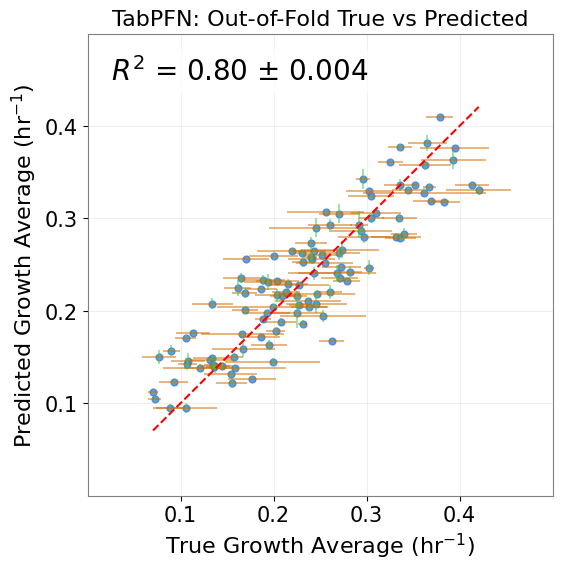

In [61]:
# TabPFN repeated-CV prediction-std diagnostic
tabpfn_cv_split_seeds = [10, 11, 12]

tabpfn_pred_sum = np.zeros(n_samples, dtype=np.float64)
tabpfn_pred_sumsq = np.zeros(n_samples, dtype=np.float64)
tabpfn_pred_count = np.zeros(n_samples, dtype=np.int32)
tabpfn_true_per_sample = np.full(n_samples, np.nan, dtype=np.float64)

tabpfn_seed_metrics = []
for cv_seed in tabpfn_cv_split_seeds:
    skf_rep = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)
    seed_true_parts = []
    seed_pred_parts = []

    for fold_id, (tr_idx, va_idx) in enumerate(skf_rep.split(np.arange(n_samples), stratify_y), start=1):
        X_train, X_val = X_all[tr_idx], X_all[va_idx]
        y_train, y_val = y_all[tr_idx], y_all[va_idx]

        reg_rep = TabPFNRegressor(random_state=cv_seed)
        reg_rep.fit(X_train, y_train)
        y_pred = reg_rep.predict(X_val).astype(np.float32)

        for idx_i, y_t, y_p in zip(va_idx, y_val, y_pred):
            if np.isnan(tabpfn_true_per_sample[idx_i]):
                tabpfn_true_per_sample[idx_i] = float(y_t)
            elif not np.isclose(tabpfn_true_per_sample[idx_i], float(y_t), atol=1e-7):
                raise ValueError(f"Conflicting true value for sample {idx_i}.")
            tabpfn_pred_sum[idx_i] += float(y_p)
            tabpfn_pred_sumsq[idx_i] += float(y_p) ** 2
            tabpfn_pred_count[idx_i] += 1

        seed_true_parts.append(y_val)
        seed_pred_parts.append(y_pred)

    seed_true = np.concatenate(seed_true_parts)
    seed_pred = np.concatenate(seed_pred_parts)
    tabpfn_seed_metrics.append({
        "cv_seed": int(cv_seed),
        "r2": float(r2_score(seed_true, seed_pred)),
        "mae": float(mean_absolute_error(seed_true, seed_pred)),
        "rmse": float(np.sqrt(np.mean((seed_true - seed_pred) ** 2))),
    })

expected_count = len(tabpfn_cv_split_seeds)
if np.any(tabpfn_pred_count != expected_count):
    bad = np.where(tabpfn_pred_count != expected_count)[0].tolist()
    raise ValueError(f"Each sample should have {expected_count} TabPFN OOF predictions; bad samples: {bad}")

tabpfn_oof_true_cv = tabpfn_true_per_sample.astype(np.float32)
tabpfn_oof_pred_mean = tabpfn_pred_sum / tabpfn_pred_count
tabpfn_oof_pred_cv = tabpfn_oof_pred_mean.astype(np.float32)
tabpfn_oof_pred_seed_var_cv = (
    tabpfn_pred_sumsq - tabpfn_pred_count * tabpfn_oof_pred_mean ** 2
) / np.maximum(1, tabpfn_pred_count - 1)
tabpfn_oof_pred_seed_std_cv = np.sqrt(np.maximum(0.0, tabpfn_oof_pred_seed_var_cv)).astype(np.float32)
tabpfn_oof_std_cv = y_std_all.astype(np.float32)

tabpfn_r2_repeated = r2_score(tabpfn_oof_true_cv, tabpfn_oof_pred_cv)
tabpfn_mae_repeated = mean_absolute_error(tabpfn_oof_true_cv, tabpfn_oof_pred_cv)
tabpfn_rmse_repeated = np.sqrt(np.mean((tabpfn_oof_true_cv - tabpfn_oof_pred_cv) ** 2))
tabpfn_seed_r2_vals = np.array([m["r2"] for m in tabpfn_seed_metrics], dtype=np.float32)
tabpfn_seed_mae_vals = np.array([m["mae"] for m in tabpfn_seed_metrics], dtype=np.float32)
tabpfn_seed_rmse_vals = np.array([m["rmse"] for m in tabpfn_seed_metrics], dtype=np.float32)
tabpfn_seed_r2_mean = float(tabpfn_seed_r2_vals.mean())
tabpfn_seed_r2_std = float(tabpfn_seed_r2_vals.std(ddof=0))
tabpfn_seed_mae_mean = float(tabpfn_seed_mae_vals.mean())
tabpfn_seed_mae_std = float(tabpfn_seed_mae_vals.std(ddof=0))
tabpfn_seed_rmse_mean = float(tabpfn_seed_rmse_vals.mean())
tabpfn_seed_rmse_std = float(tabpfn_seed_rmse_vals.std(ddof=0))
tabpfn_pred_seed_std_mean = float(np.mean(tabpfn_oof_pred_seed_std_cv))
tabpfn_pred_seed_std_std = float(np.std(tabpfn_oof_pred_seed_std_cv))

print("TabPFN repeated-CV seed metrics:")
for m in tabpfn_seed_metrics:
    print(f"cv_seed={m['cv_seed']} | R2={m['r2']:.4f} | MAE={m['mae']:.6f} | RMSE={m['rmse']:.6f}")
print(f"TabPFN pooled OOF across split seeds | R2: {tabpfn_seed_r2_mean:.4f} +/- {tabpfn_seed_r2_std:.4f}")
print(f"TabPFN pooled OOF across split seeds | MAE: {tabpfn_seed_mae_mean:.6f} +/- {tabpfn_seed_mae_std:.6f}")
print(f"TabPFN pooled OOF across split seeds | RMSE: {tabpfn_seed_rmse_mean:.6f} +/- {tabpfn_seed_rmse_std:.6f}")
print(f"TabPFN repeated-CV mean-prediction R2: {tabpfn_r2_repeated:.4f}")
print(f"TabPFN repeated-CV mean-prediction MAE: {tabpfn_mae_repeated:.6f}")
print(f"TabPFN repeated-CV mean-prediction RMSE: {tabpfn_rmse_repeated:.6f}")
print(f"TabPFN prediction std across split seeds: mean={tabpfn_pred_seed_std_mean:.6f} +/- {tabpfn_pred_seed_std_std:.6f}")

from pathlib import Path
out_dir = Path("./insights/thesis")
out_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 6))
line_min_tabpfn = float(max(0.0, min(tabpfn_oof_true_cv.min(), tabpfn_oof_pred_cv.min())))
line_max_tabpfn = float(min(0.5, max(tabpfn_oof_true_cv.max(), tabpfn_oof_pred_cv.max())))

plt.hlines(
    y=tabpfn_oof_pred_cv,
    xmin=tabpfn_oof_true_cv - tabpfn_oof_std_cv,
    xmax=tabpfn_oof_true_cv + tabpfn_oof_std_cv,
    colors="#CC6E00",
    alpha=0.6,
    linewidth=1.2,
)
plt.vlines(
    x=tabpfn_oof_true_cv,
    ymin=tabpfn_oof_pred_cv - tabpfn_oof_pred_seed_std_cv,
    ymax=tabpfn_oof_pred_cv + tabpfn_oof_pred_seed_std_cv,
    colors="#3ECC40",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(tabpfn_oof_true_cv, tabpfn_oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([line_min_tabpfn, line_max_tabpfn], [line_min_tabpfn, line_max_tabpfn], "r--", lw=1.5)
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
plt.ylabel(r"Predicted Growth Average (hr$^{-1}$)", fontsize=16)
plt.title("TabPFN: Out-of-Fold True vs Predicted", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, format_r2_with_std(tabpfn_seed_r2_mean, tabpfn_seed_r2_std), transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=20,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.savefig(out_dir / "iML1515_tabpfn_oof_true_vs_predicted_with_exp_and_seed_std_bars.png", dpi=300, bbox_inches="tight")
plt.show()


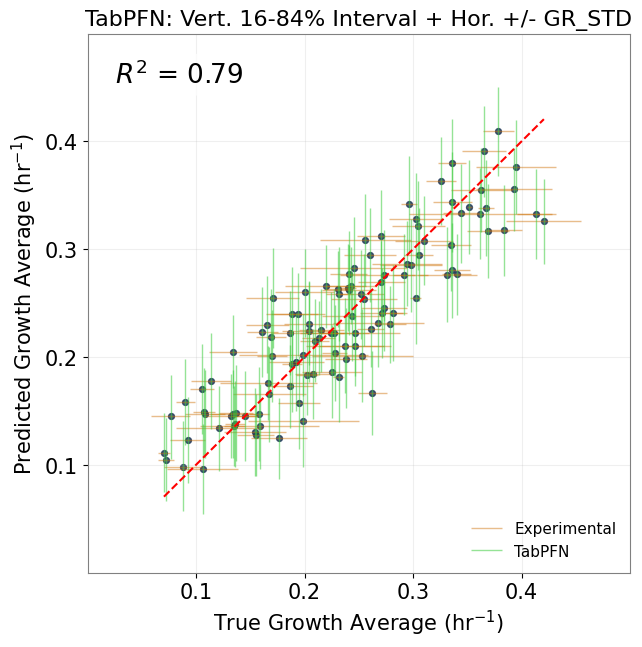

In [62]:
# TabPFN uncertainty diagnostics (OOF): prediction intervals per OOF point only
# Requires cell 30 to be run first (defines feature_cols, stratify_y, n_splits, X_all, y_all, y_std_all).

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor

q_list = [0.16, 0.50, 0.84]

def _to_quantile_dict(pred_q, quantiles):
    if isinstance(pred_q, dict):
        if "quantiles" in pred_q:
            q_vals = pred_q["quantiles"]
            return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, q_vals)}
        if "predictions" in pred_q:
            q_vals = pred_q["predictions"]
            return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, q_vals)}
        out = {}
        for k, v in pred_q.items():
            try:
                qk = float(k)
                out[qk] = np.asarray(v).reshape(-1)
            except Exception:
                pass
        if len(out) > 0:
            return out
        raise ValueError("Unsupported quantile dict format returned by TabPFNRegressor.predict().")

    if isinstance(pred_q, (list, tuple)):
        return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, pred_q)}

    arr = np.asarray(pred_q)
    if arr.ndim == 2 and arr.shape[1] == len(quantiles):
        return {float(q): arr[:, i].reshape(-1) for i, q in enumerate(quantiles)}

    raise ValueError("Unsupported quantile output format from TabPFNRegressor.predict().")


# Build OOF quantiles fold-by-fold
skf_uq = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=10)

oof_true_uq_parts = []
oof_std_uq_parts = []
oof_q_parts = {q: [] for q in q_list}

for fold_id, (tr_idx, va_idx) in enumerate(skf_uq.split(np.arange(X_all.shape[0]), stratify_y), start=1):
    X_train, X_val = X_all[tr_idx], X_all[va_idx]
    y_train, y_val = y_all[tr_idx], y_all[va_idx]

    reg_uq = TabPFNRegressor(random_state=10)
    reg_uq.fit(X_train, y_train)

    try:
        q_pred_raw = reg_uq.predict(X_val, output_type="quantiles", quantiles=q_list)
    except TypeError:
        q_pred_raw = reg_uq.predict(X_val, quantiles=q_list)

    q_pred = _to_quantile_dict(q_pred_raw, q_list)

    oof_true_uq_parts.append(y_val)
    oof_std_uq_parts.append(y_std_all[va_idx])
    for q in q_list:
        if q not in q_pred:
            raise ValueError(f"Quantile {q} missing in TabPFN output for fold {fold_id}.")
        oof_q_parts[q].append(np.asarray(q_pred[q], dtype=np.float32).reshape(-1))

oof_true_uq = np.concatenate(oof_true_uq_parts)
oof_std_uq = np.concatenate(oof_std_uq_parts)
oof_q = {q: np.concatenate(parts) for q, parts in oof_q_parts.items()}

pred_q16 = oof_q[0.16]
pred_q84 = oof_q[0.84]
r2_uq = r2_score(oof_true_tabpfn, oof_pred_tabpfn)
mae_uq = mean_absolute_error(oof_true_tabpfn, oof_pred_tabpfn)

# Prediction intervals per OOF point: vertical model interval + horizontal +/- GR_STD
plt.figure(figsize=(7, 7))

# Horizontal bars = experimental uncertainty (+/- GR_STD)
plt.hlines(
    y=oof_pred_tabpfn,
    xmin=oof_true_uq - oof_std_uq,
    xmax=oof_true_uq + oof_std_uq,
    colors="#CC6E00",
    alpha=0.45,
    linewidth=1.0,
    label="Experimental",
)

# Vertical bars = model predictive interval (q16-q84)
plt.vlines(
    x=oof_true_uq,
    ymin=pred_q16,
    ymax=pred_q84,
    colors="#3ECC40",
    alpha=0.55,
    linewidth=1.0,
    label="TabPFN",
)

# Point predictions from cell 30
plt.scatter(
    oof_true_uq,
    oof_pred_tabpfn,
    s=18,
    alpha=0.8,
    color="#1D3557",
    label="_nolegend_",
)

line_min_v = float(max(0.0, min(oof_true_uq.min(), oof_pred_tabpfn.min())))
line_max_v = float(min(0.5, max(oof_true_uq.max(), oof_pred_tabpfn.max())))
plt.plot([line_min_v, line_max_v], [line_min_v, line_max_v], "r--", lw=1.5, label="_nolegend_")
plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=15)
plt.ylabel(r"Predicted Growth Average (hr$^{-1}$)", fontsize=15)
plt.title("TabPFN: Vert. 16-84% Interval + Hor. +/- GR_STD", fontsize=16)
plt.xlim(0.0, 0.5)
plt.ylim(0.0, 0.5)
plt.text(0.05, 0.95, f"$R^2$ = {r2_uq:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=19,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.legend(frameon=False, fontsize=11, loc="lower right")
plt.grid(alpha=0.2)
plt.show()


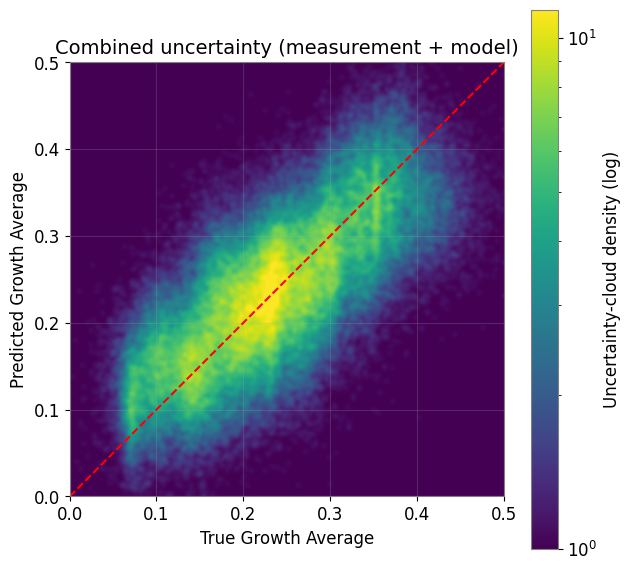

In [63]:
rng = np.random.default_rng(10)
n_draw = 1000
sigma_model = 0.5 * (pred_q84 - pred_q16)

x_cloud = (oof_true_uq[:,None] + rng.normal(0, oof_std_uq[:,None], (len(oof_true_uq), n_draw))).ravel()
y_cloud = (oof_pred_tabpfn[:,None] + rng.normal(0, sigma_model[:,None], (len(oof_true_uq), n_draw))).ravel()

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm

H, xedges, yedges = np.histogram2d(x_cloud, y_cloud, bins=300, range=[[0,0.5],[0,0.5]])
H = gaussian_filter(H, sigma=1.6)
vmax = np.percentile(H, 99.7) + 1

plt.figure(figsize=(7,7))
im = plt.imshow((H.T + 1), origin="lower", extent=[0,0.5,0,0.5], cmap="viridis",
                norm=LogNorm(vmin=1, vmax=vmax), interpolation="lanczos", aspect="equal")
cbar = plt.colorbar(im)
cbar.set_label("Uncertainty-cloud density (log)", fontsize=12)
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_edgecolor("gray")
plt.plot([0,0.5],[0,0.5],"r--",lw=1.5)
plt.xlim(0,0.5); plt.ylim(0,0.5)
plt.xlabel("True Growth Average", fontsize=12)
plt.ylabel("Predicted Growth Average", fontsize=12)
plt.title("Combined uncertainty (measurement + model)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("gray")
plt.grid(alpha=0.2)
plt.show()
